<a href="https://colab.research.google.com/github/Cruzada04/TF_Business-Predictive-Analytics/blob/main/BPA_TF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Trabajo Final**
####**Business Predictive Analytics**
#####*Grupo 2*

##**Entendimiento del negocio**
####**Contexto del problema**
Las startups y proyectos de crowdfunding enfrentan tasas de fracaso críticas (42.48% en Kickstarter) debido a que los creadores suelen depender de la intuición discursiva en lugar de parámetros estadísticos validados al momento de buscar capital.

####**Objetivo del Proyecto**
Desarrollar un modelo predictivo de Machine Learning que funcione como un auditor preventivo.


##**Comprensión de los Datos**

###**Configuración del Entorno**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from textblob import TextBlob

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import randint, uniform, loguniform

pd.options.display.float_format = '{:,.2f}'.format

In [7]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###**Fuente de datos y mecanismo de recolección**

In [8]:
INPUT_ROUTE = "/content/drive/MyDrive/EF/bpa_tf/Kickstarter Projects_639378_Aug 2025 Updated.csv"
df = pd.read_csv(INPUT_ROUTE)

/tmp/ipykernel_9479/4233672126.py:2: DtypeWarning: Columns (7,28,30,32,35,36,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_ROUTE)


###**Estructura de datos en bruto**

In [9]:
print(f"Dimensiones en bruto del dataset: \n Filas: {df.shape[0]} \n Columnas: {df.shape[1]}\n")

Dimensiones en bruto del dataset: 
 Filas: 639378 
 Columnas: 43



In [10]:
# Se imprimen los primeros 5 registros
df.head()

,collected_at,backers_count,blurb,category_id,category_name,category_parent_id,category_parent_name,category_url,converted_pledged_amount,country,...,profile_state_changed_at,project_url,spotlight,staff_pick,state,state_changed_at,static_usd_rate,usd_exchange_rate,usd_pledged,usd_type
0,202508,0,A digital pixel artbook with 100+ retro charac...,21.00,Digital Art,1,Art,http://www.kickstarter.com/discover/categories...,0.00,GR,...,"1,751,381,676.00",https://www.kickstarter.com/projects/166561044...,False,False,live,1755171041,1.17,1.17,0.00,domestic
1,202508,4,"Remote controlled, battery operated lawnmower ...",338.00,Robots,16,Technology,http://www.kickstarter.com/discover/categories...,"3,011.00",US,...,"1,515,463,352.00",https://www.kickstarter.com/projects/lawnmower...,False,False,failed,1521579553,1.00,1.00,"3,011.00",domestic
2,202508,12,3rd Generation of SoundDuino. Audio shield for...,52.00,Hardware,16,Technology,http://www.kickstarter.com/discover/categories...,870.00,US,...,"1,481,399,518.00",https://www.kickstarter.com/projects/67935456/...,True,False,successful,1481398619,1.00,1.00,870.00,domestic
3,202508,202,Do you want to learn to code in some of the ea...,NaN,NaN,16,Technology,http://www.kickstarter.com/discover/categories...,"10,103.00",CA,...,"1,556,570,666.00",https://www.kickstarter.com/projects/johnbura/...,True,False,successful,1478149200,0.76,0.75,"10,316.63",domestic
4,202508,145,The motion sensor build-in Wi-Fi hardware. Use...,334.00,DIY Electronics,16,Technology,http://www.kickstarter.com/discover/categories...,"2,394.00",HK,...,"1,476,370,785.00",https://www.kickstarter.com/projects/kwankk/ne...,True,False,successful,1479312688,0.13,0.13,"2,394.24",domestic


In [11]:
# Se imprimen los últimos 5 registros
df.tail()

,collected_at,backers_count,blurb,category_id,category_name,category_parent_id,category_parent_name,category_url,converted_pledged_amount,country,...,profile_state_changed_at,project_url,spotlight,staff_pick,state,state_changed_at,static_usd_rate,usd_exchange_rate,usd_pledged,usd_type
639373,201404,48,Project cancelled on Kickstarter.,31.00,narrative film,11,Film & Video,NaN,NaN,GB,...,NaN,https://www.kickstarter.com/projects/153007399...,NaN,NaN,canceled,1379792780,NaN,1.67,"8,620.17",NaN
639374,201404,23,Bean Lab Coffee Roasters is a new startup Micr...,NaN,NaN,10,Food,NaN,NaN,US,...,NaN,https://www.kickstarter.com/projects/945309886...,NaN,NaN,failed,1334358422,NaN,1.00,"1,670.00",NaN
639375,201404,13,Classical Actors Ensemble presents John Ford's...,NaN,NaN,17,Theater,NaN,NaN,US,...,NaN,https://www.kickstarter.com/projects/159381620...,NaN,NaN,successful,1290315610,NaN,1.00,502.00,NaN
639376,201404,118,Phase I of a groundbreaking new documentary pr...,30.00,documentary,11,Film & Video,NaN,NaN,US,...,NaN,https://www.kickstarter.com/projects/200414682...,NaN,NaN,successful,1342116050,NaN,1.00,"11,805.00",NaN
639377,201404,10,Niki English has entered the Sol Inpirations E...,NaN,NaN,9,Fashion,NaN,NaN,US,...,NaN,https://www.kickstarter.com/projects/nikiengli...,NaN,NaN,successful,1301760016,NaN,1.00,818.00,NaN


In [12]:
# Se imprimen las columnas y su tipo de dato
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639378 entries, 0 to 639377
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   collected_at              639378 non-null  int64  
 1   backers_count             639378 non-null  int64  
 2   blurb                     639311 non-null  object 
 3   category_id               532857 non-null  float64
 4   category_name             532857 non-null  object 
 5   category_parent_id        639378 non-null  int64  
 6   category_parent_name      639378 non-null  object 
 7   category_url              593837 non-null  object 
 8   converted_pledged_amount  575601 non-null  float64
 9   country                   639378 non-null  object 
 10  created_at                639378 non-null  int64  
 11  creator_id                639378 non-null  int64  
 12  creator_name              639375 non-null  object 
 13  creator_url               639378 non-null  o

##**Calidad y Limpieza de datos**

###**Limpieza inicial de datos**

In [13]:
# Eliminación de variables irrelevantes que están fuera del alcance

irrelevant_columns = [
    # 1. Identificadores y metadatos (No aportan valor predictivo generalizable)
    'id',                       # ID único del proyecto
    'creator_id',               # ID único del creador
    'profile_id',               # ID único del perfil asociado
    'profile_project_id',       # ID redundante del proyecto en el perfil
    'creator_name',             # Nombre propio del creador
    'profile_name',             # Nombre propio del perfil
    'project_url',              # Enlace web del proyecto
    'creator_url',              # Enlace web del creador
    'category_url',             # Enlace web de la categoría
    'collected_at',             # Fecha en la que el scraper extrajo los datos
    'profile_blurb',            # Descripción del perfil
    'profile_state',            # Estado interno del perfil en el sistema de Kickstarter
    'location_id',             # ID único de la ubicación
    'location_type',            # Tipo de ubicación
    'category_id',              # ID único de la categoría
    'category_parent_id',       # ID único de la categoría padre
    'usd_type',                 # Tipo de moneda en USD
    'location_country',  # País de origen
    'location_name', # Provincia o región
    'location_state', # Estado de país

    # 2. Variables post-lanzamiento / Prevención de Fuga de Datos (Data Leakage)
    'backers_count',            # Total de patrocinadores (solo se conoce con la campaña en marcha/finalizada)
    'pledged',                  # Dinero real recaudado (moneda local)
    'usd_pledged',              # Dinero real recaudado en USD
    'converted_pledged_amount', # Monto recaudado convertido (redundante)
    'percent_funded',           # Porcentaje de la meta que se logró financiar
    'spotlight',                # Etiqueta otorgada por la plataforma exclusivamente tras el éxito del proyecto
    'staff_pick',               # Selección editorial (suele asignarse cuando la campaña ya tiene tracción)
    'state_changed_at',         # Fecha en la que el proyecto cambió a su estado final
    'profile_state_changed_at', # Fecha en la que el perfil cambió a su estado final
]

# Asumiendo que tu dataframe base al cargarlo se llama 'df'
df_init = df.drop(columns=irrelevant_columns)

df_init.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639378 entries, 0 to 639377
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 639311 non-null  object 
 1   category_name         532857 non-null  object 
 2   category_parent_name  639378 non-null  object 
 3   country               639378 non-null  object 
 4   created_at            639378 non-null  int64  
 5   currency              639378 non-null  object 
 6   deadline              639378 non-null  int64  
 7   fx_rate               584645 non-null  float64
 8   goal                  639378 non-null  float64
 9   launched_at           639378 non-null  int64  
 10  name                  639372 non-null  object 
 11  state                 639378 non-null  object 
 12  static_usd_rate       600010 non-null  float64
 13  usd_exchange_rate     573294 non-null  float64
dtypes: float64(4), int64(3), object(7)
memory usage: 68.

In [14]:
#Eliminación de registros que están fuera del alcance

#Filtrado de solo registros con origen en USA
df_init = df_init[df_init['country'] == 'US']

#Filtrado de registros con estados que no sean 'successful' y 'failed'
df_init = df_init[df_init['state'].isin(['successful', 'failed'])]

print(f"Dimensiones tras limpieza inicial del dataset: \n Filas: {df_init.shape[0]} \n Columnas: {df_init.shape[1]}\n")

Dimensiones tras limpieza inicial del dataset: 
 Filas: 380915 
 Columnas: 14



In [15]:
#Cambiar tipos de datos de la variable

#Variables temporales (int a datetime)
df_init['created_at'] = pd.to_datetime(df_init['created_at'], unit='s')
df_init['launched_at'] = pd.to_datetime(df_init['launched_at'], unit='s')
df_init['deadline'] = pd.to_datetime(df_init['deadline'], unit='s')

#Variable target (object a int)
df_init['state'] = df_init['state'].map({'successful': 1, 'failed': 0})
df_init['state'] = df_init['state'].astype(int)

df_init.info()

<class 'pandas.core.frame.DataFrame'>
Index: 380915 entries, 1 to 639377
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   blurb                 380908 non-null  object        
 1   category_name         311211 non-null  object        
 2   category_parent_name  380915 non-null  object        
 3   country               380915 non-null  object        
 4   created_at            380915 non-null  datetime64[ns]
 5   currency              380915 non-null  object        
 6   deadline              380915 non-null  datetime64[ns]
 7   fx_rate               343716 non-null  float64       
 8   goal                  380915 non-null  float64       
 9   launched_at           380915 non-null  datetime64[ns]
 10  name                  380912 non-null  object        
 11  state                 380915 non-null  int64         
 12  static_usd_rate       352632 non-null  float64       
 13  usd_

###**Análisis de valores nulos y duplicados**

In [16]:
# Análisis de valores nulos
pd.concat([df_init.isnull().sum().sort_values(ascending=False), 100*df_init.isnull().mean()], axis=1)

,0,1
category_name,69704,18.30
fx_rate,37199,9.77
usd_exchange_rate,30826,8.09
static_usd_rate,28283,7.43
blurb,7,0.00
name,3,0.00
currency,0,0.00
created_at,0,0.00
country,0,0.00
category_parent_name,0,0.00


In [17]:
# Análisis de valores duplicados
rate_duplicated = df_init.duplicated(keep=False).sum() / len(df_init)
print(f"Tasa de duplicados: {rate_duplicated:.4f}")

Tasa de duplicados: 0.0000


###**Análisis de calidad de variables numéricas y categóricas**

In [18]:
#Análisis de variables numéricas
df_init.describe()

,created_at,deadline,fx_rate,goal,launched_at,state,static_usd_rate,usd_exchange_rate
count,380915,380915,"343,716.00","380,915.00",380915,"380,915.00","352,632.00","350,089.00"
mean,2016-08-08 05:13:26.009385472,2016-11-04 08:06:51.236680192,0.99,"31,883.10",2016-10-01 16:16:05.410078464,0.50,1.00,0.99
min,2009-04-21 17:00:19,2009-05-03 06:59:59,0.00,0.01,2009-04-21 19:02:48,0.00,1.00,0.00
25%,2013-05-29 06:48:19,2013-08-31 17:13:31.500000,1.00,"1,900.00",2013-07-30 17:53:42,0.00,1.00,1.00
50%,2015-08-20 17:13:18,2015-11-15 18:57:22,1.00,"5,000.00",2015-10-14 02:10:37,1.00,1.00,1.00
75%,2019-07-08 22:31:16,2019-10-09 09:34:41,1.00,"14,000.00",2019-09-04 17:02:41.500000,1.00,1.00,1.00
max,2025-08-05 17:31:53,2025-08-14 13:00:03,1.38,"100,000,000.00",2025-08-08 21:10:47,1.00,1.00,1.00
std,NaN,NaN,0.10,"866,854.11",NaN,0.50,0.00,0.10


In [19]:
#Análisis de variables categóricas
df_init.describe(include='object')

,blurb,category_name,category_parent_name,country,currency,name
count,380908,311211,380915,380915,380915,380912
unique,376312,176,16,1,1,378611
top,Help support the largest creative collaboratio...,Tabletop Games,Film & Video,US,USD,#NAME?
freq,52,26022,57454,380915,380915,28


###**Ingeniería de características: Crear variables numéricas a partir las variables temporales**

In [20]:
# Creamos métricas numéricas a partir de las fechas y textos originales
df_second = df_init.copy()

df_second['duration_days'] = (df_init['deadline'] - df_init['launched_at']).dt.days
df_second['preparation_days'] = (df_init['launched_at'] - df_init['created_at']).dt.days
df_second['name_len'] = df_init['name'].astype(str).str.len()
df_second['blurb_len'] = df_init['blurb'].astype(str).str.len()
df_second['launch_month'] = df_init['launched_at'].dt.month
df_second['launch_dayofweek'] = df_init['launched_at'].dt.dayofweek

#Eliminamos las variables anteriores
df_second = df_second.drop(columns=['created_at', 'launched_at', 'deadline'])

df_second.info()

<class 'pandas.core.frame.DataFrame'>
Index: 380915 entries, 1 to 639377
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 380908 non-null  object 
 1   category_name         311211 non-null  object 
 2   category_parent_name  380915 non-null  object 
 3   country               380915 non-null  object 
 4   currency              380915 non-null  object 
 5   fx_rate               343716 non-null  float64
 6   goal                  380915 non-null  float64
 7   name                  380912 non-null  object 
 8   state                 380915 non-null  int64  
 9   static_usd_rate       352632 non-null  float64
 10  usd_exchange_rate     350089 non-null  float64
 11  duration_days         380915 non-null  int64  
 12  preparation_days      380915 non-null  int64  
 13  name_len              380915 non-null  int64  
 14  blurb_len             380915 non-null  int64  
 15  launc

##**EDA**

###**Análisis univariado**

/tmp/ipykernel_9479/1668718730.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_second, x='launch_month', ax=axes[1,1], palette='viridis')
/tmp/ipykernel_9479/1668718730.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_second, x='launch_dayofweek', ax=axes[1,2], palette='magma')
/tmp/ipykernel_9479/1668718730.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_second, x='state', ax=axes[2,0], palette='Set2')
/tmp/ipykernel_9479/1668718730.py:38: FutureWarning: 

Passing `palette` without assigning `hue`

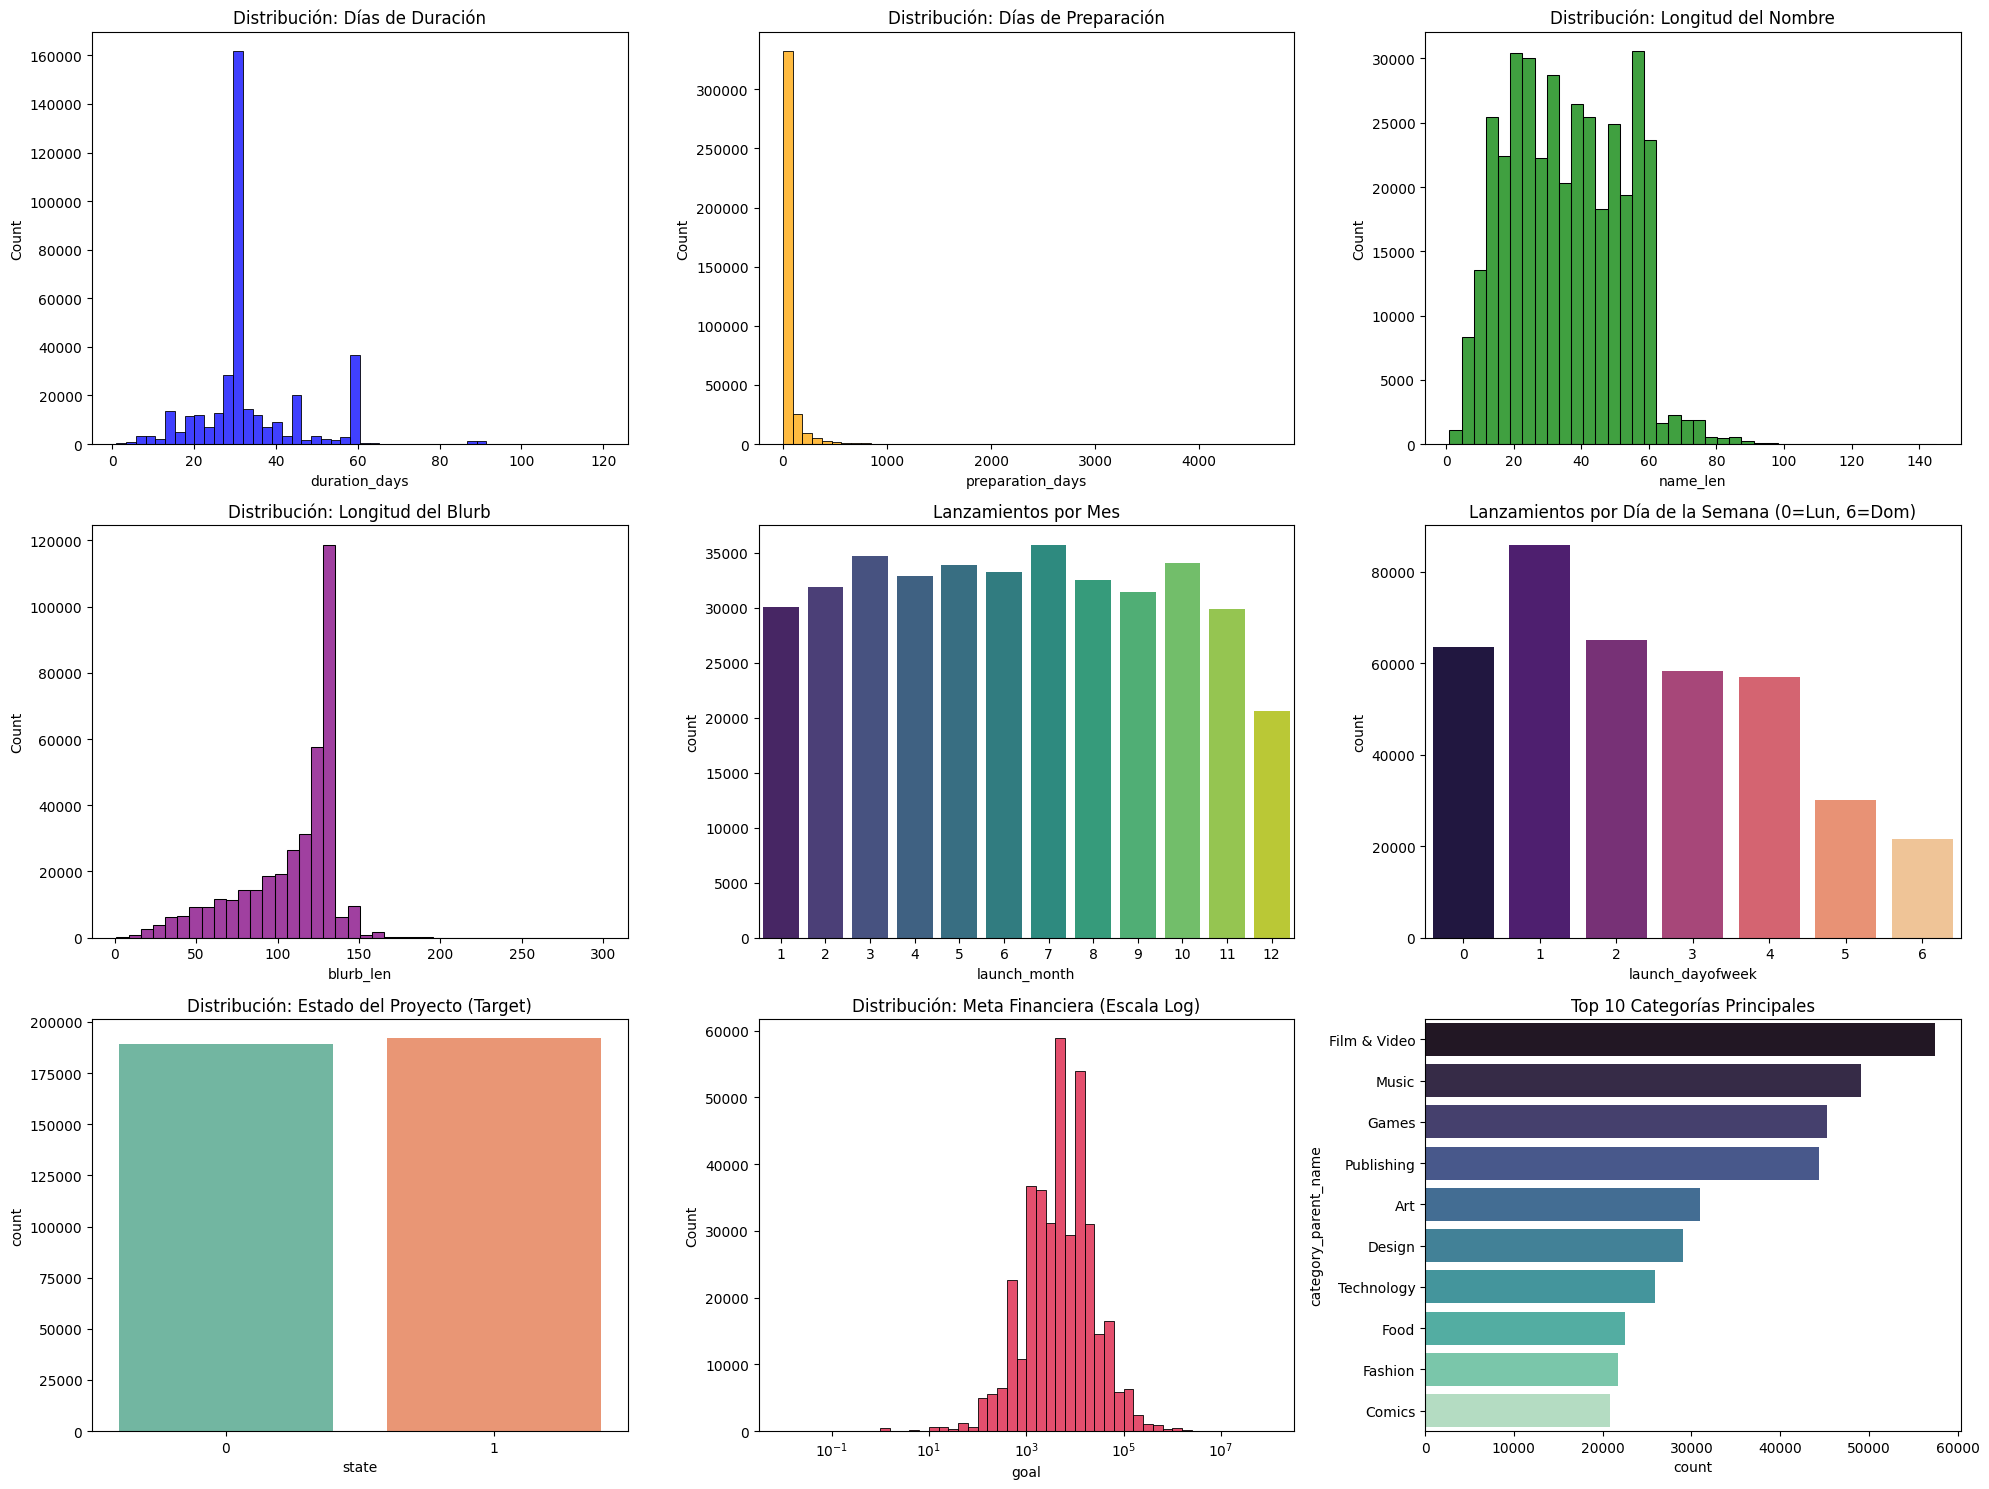

In [21]:
# Aumentamos un poco el alto (figsize) para que las 3 filas respiren bien
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

# --- Fila 1: Días y Textos ---
sns.histplot(df_second['duration_days'], bins=50, ax=axes[0,0], color='blue')
axes[0,0].set_title('Distribución: Días de Duración')

sns.histplot(df_second['preparation_days'], bins=50, ax=axes[0,1], color='orange')
axes[0,1].set_title('Distribución: Días de Preparación')

sns.histplot(df_second['name_len'], bins=40, ax=axes[0,2], color='green')
axes[0,2].set_title('Distribución: Longitud del Nombre')


# --- Fila 2: Textos y Fechas ---
sns.histplot(df_second['blurb_len'], bins=40, ax=axes[1,0], color='purple')
axes[1,0].set_title('Distribución: Longitud del Blurb')

sns.countplot(data=df_second, x='launch_month', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Lanzamientos por Mes')

sns.countplot(data=df_second, x='launch_dayofweek', ax=axes[1,2], palette='magma')
axes[1,2].set_title('Lanzamientos por Día de la Semana (0=Lun, 6=Dom)')


# --- Fila 3: Target, Finanzas y Categorías ---

# 1. Variable Objetivo (Target)
sns.countplot(data=df_second, x='state', ax=axes[2,0], palette='Set2')
axes[2,0].set_title('Distribución: Estado del Proyecto (Target)')

# 2. Meta Financiera (goal)
sns.histplot(data=df_second, x='goal', bins=50, log_scale=True, ax=axes[2,1], color='crimson')
axes[2,1].set_title('Distribución: Meta Financiera (Escala Log)')

# 3. Categorías (Top 10 para no saturar el eje Y)
top_categories = df_second['category_parent_name'].value_counts().nlargest(10).index
sns.countplot(data=df_second, y='category_parent_name', order=top_categories, ax=axes[2,2], palette='mako')
axes[2,2].set_title('Top 10 Categorías Principales')

plt.tight_layout()
plt.show()

###**Análisis bivariado**

/tmp/ipykernel_9479/1769766619.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_second, x='state', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_9479/1769766619.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_second, x='state', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_9479/1769766619.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_second, x='state', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_9479/1769766619.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

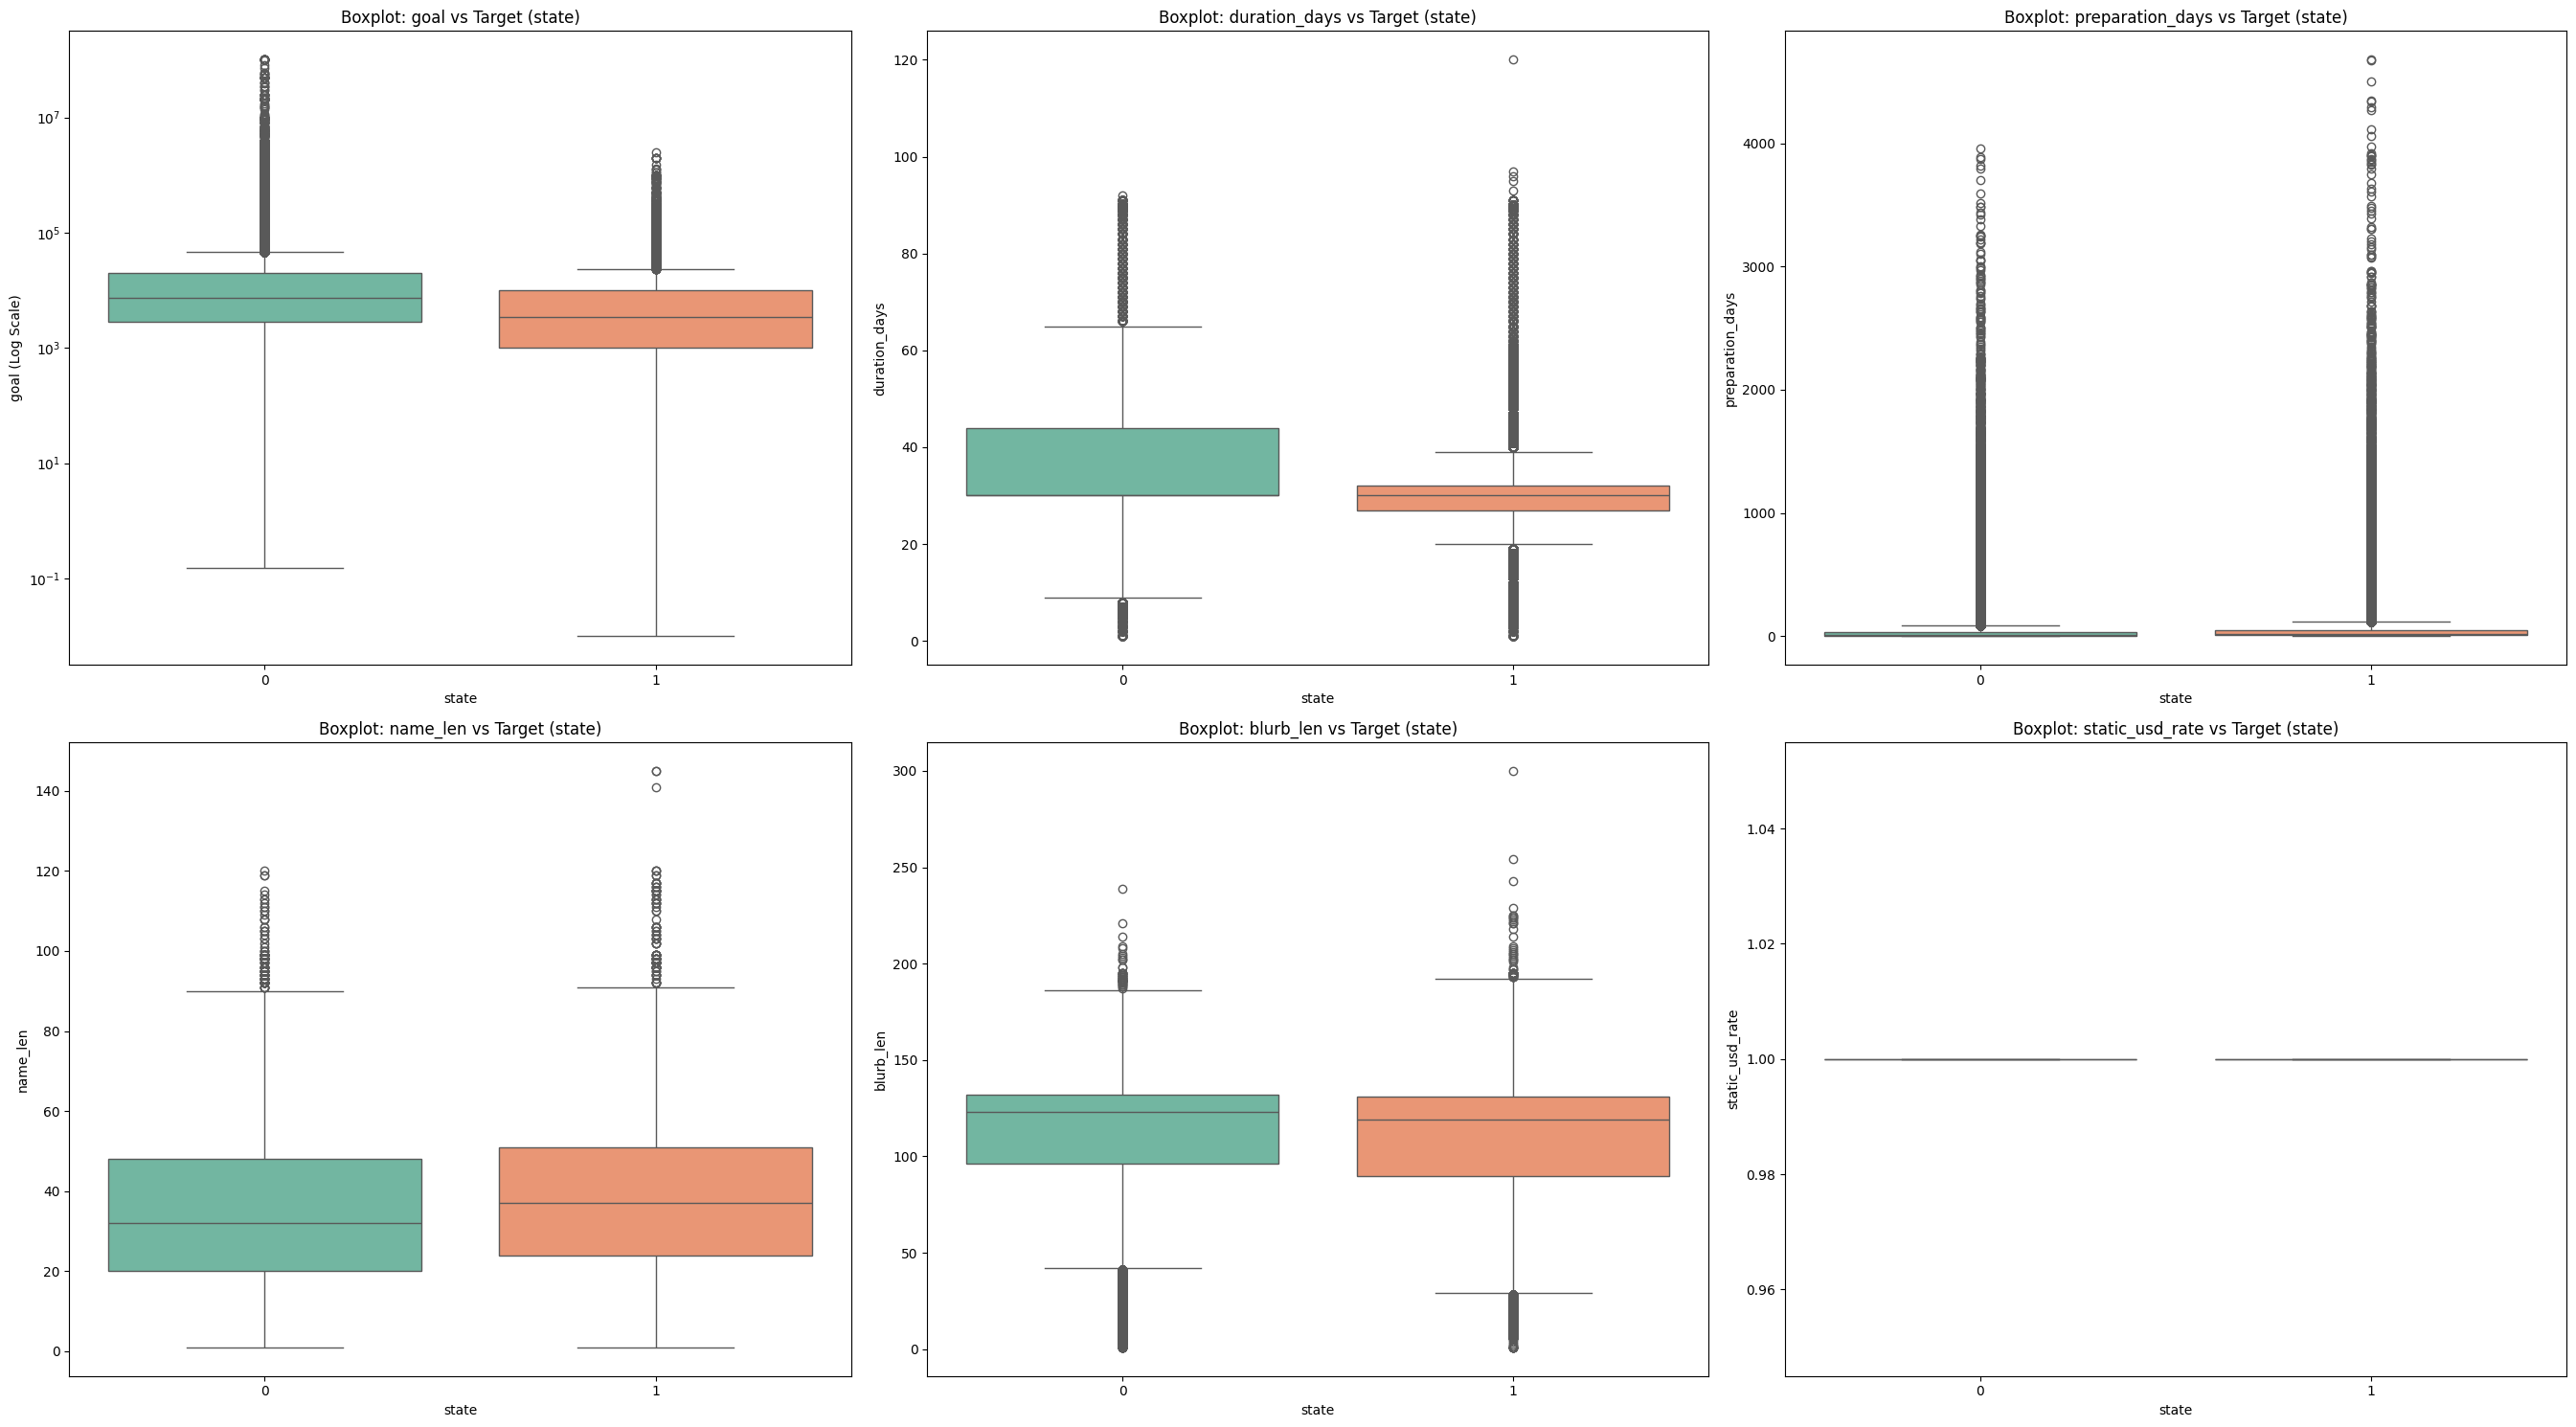

In [22]:
# Definimos las variables numéricas a analizar
num_cols = ['goal', 'duration_days', 'preparation_days', 'name_len', 'blurb_len', 'static_usd_rate']

# Creamos un grid de 2 filas x 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(27, 15))
axes = axes.flatten() # Aplanamos el array de ejes para iterar fácilmente

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_second, x='state', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Boxplot: {col} vs Target (state)')
    axes[i].set_ylabel(col)

    # Aplicamos escala logarítmica solo a variables monetarias/de mucha dispersión
    if col in ['goal']:
        axes[i].set_yscale('log')
        axes[i].set_ylabel(f'{col} (Log Scale)')

plt.tight_layout()
plt.show()

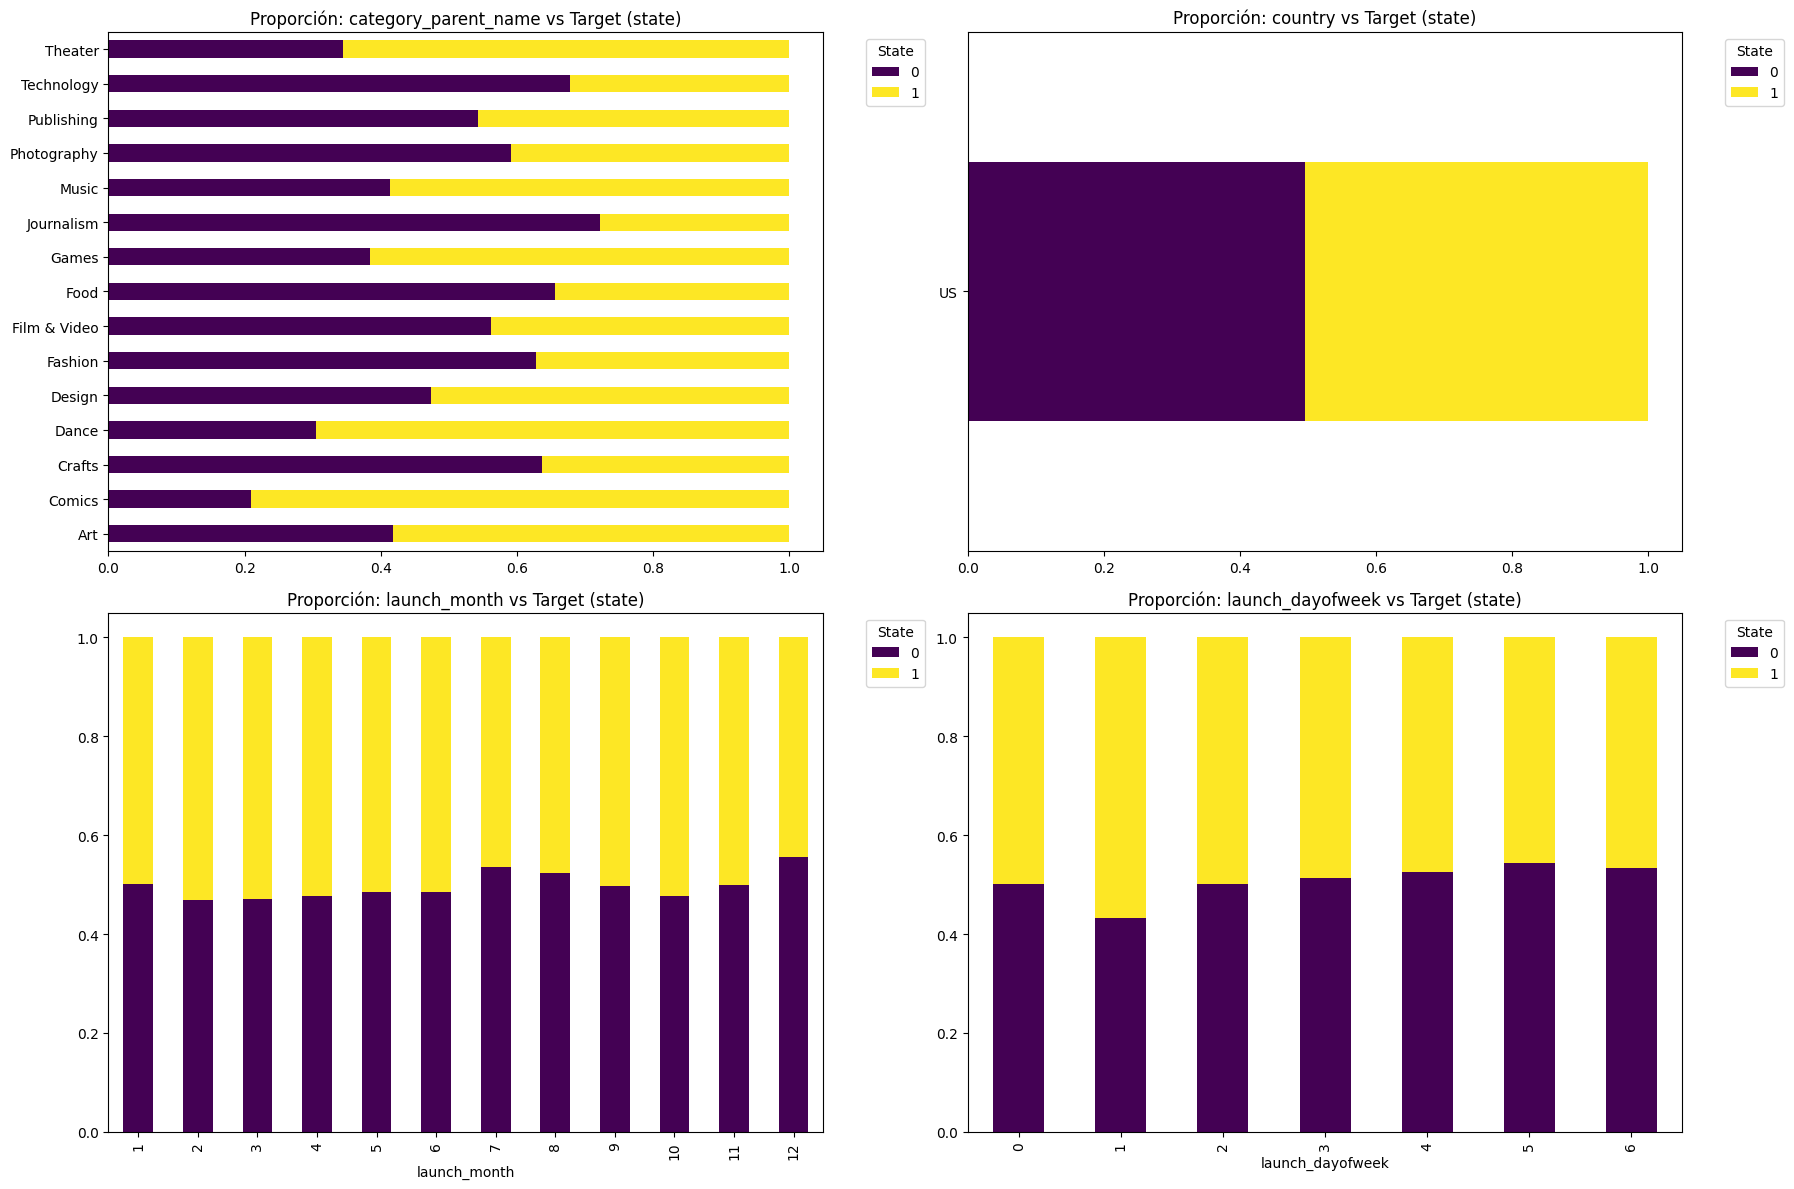

In [23]:
# Definimos las variables categóricas principales (incluyendo fechas extraídas)
cat_cols = ['category_parent_name', 'country', 'launch_month', 'launch_dayofweek']

# Creamos un grid de 2 filas x 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Si la variable tiene muchas categorías, tomamos el Top 15 para la visualización
    top_cats = df_second[col].value_counts().nlargest(15).index
    df_subset = df_second[df_second[col].isin(top_cats)]

    # Tabla cruzada normalizada al 100% por fila
    cross_tab = pd.crosstab(df_subset[col], df_subset['state'], normalize='index')

    # Decidimos la orientación: horizontal para textos largos, vertical para meses/días
    if col in ['category_parent_name', 'country']:
        cross_tab.plot(kind='barh', stacked=True, ax=axes[i], colormap='viridis')
        axes[i].set_ylabel('') # Limpiamos el texto del eje Y para que se vea mejor
    else:
        cross_tab.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis')

    axes[i].set_title(f'Proporción: {col} vs Target (state)')

    # Movemos la leyenda fuera del gráfico
    axes[i].legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

###**Análisis multivariado**

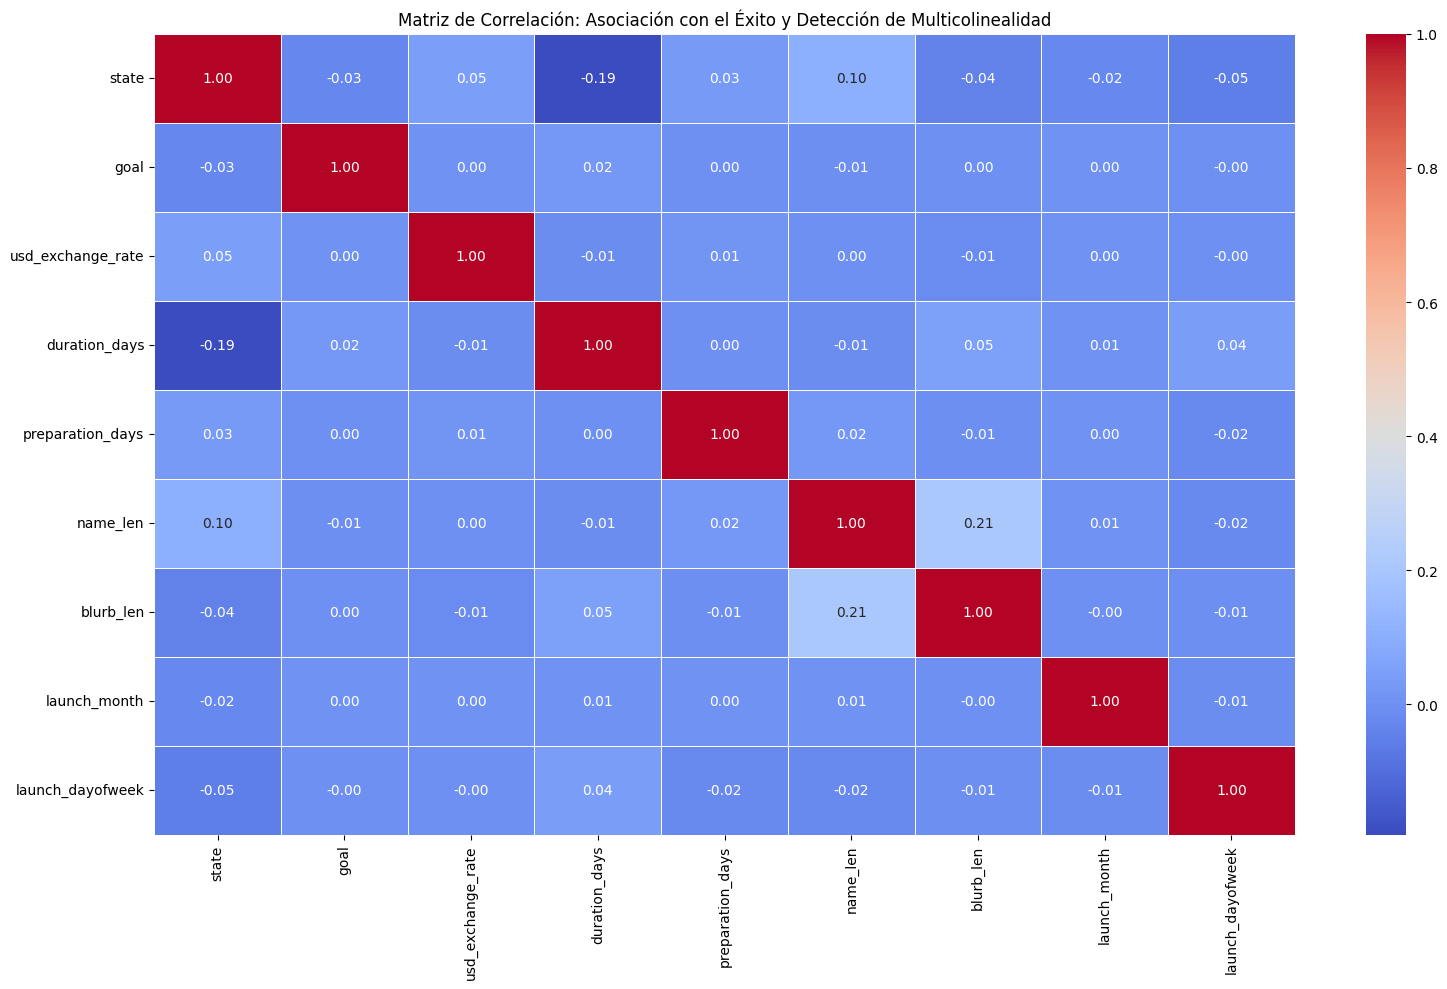

Registros procesados: 380915
Variables analizadas: state, goal, usd_exchange_rate, duration_days, preparation_days, name_len, blurb_len, launch_month, launch_dayofweek


In [24]:
plt.figure(figsize=(16, 10))

# 2. Selección de variables (Incluimos el Target 'state')
variables_analisis = [
    'state', 'goal', 'usd_exchange_rate', 'duration_days',
    'preparation_days', 'name_len', 'blurb_len',
    'launch_month', 'launch_dayofweek'
]

# 3. Matriz de Correlación: Asociación y Multicolinealidad
plt.subplot(1, 1, 1)
# Calculamos la correlación de Pearson según la metodología de clase
corr_matrix = df_second[variables_analisis].corr(method='pearson')

# Generación del Heatmap visual
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación: Asociación con el Éxito y Detección de Multicolinealidad')

plt.tight_layout()
plt.show()

# Resumen sencillo
print(f"Registros procesados: {len(df_second)}")
print(f"Variables analizadas: {', '.join(variables_analisis)}")

##**Transformación de los datos**

###**Eliminación de variables**

In [25]:
# Borrar columnas con un porcentaje de nulos mayor a  85%
df_third = df_second.copy()

columnas_a_borrar = ['category_name']
df_third = df_third.drop(columns=columnas_a_borrar)

df_third.info()

<class 'pandas.core.frame.DataFrame'>
Index: 380915 entries, 1 to 639377
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 380908 non-null  object 
 1   category_parent_name  380915 non-null  object 
 2   country               380915 non-null  object 
 3   currency              380915 non-null  object 
 4   fx_rate               343716 non-null  float64
 5   goal                  380915 non-null  float64
 6   name                  380912 non-null  object 
 7   state                 380915 non-null  int64  
 8   static_usd_rate       352632 non-null  float64
 9   usd_exchange_rate     350089 non-null  float64
 10  duration_days         380915 non-null  int64  
 11  preparation_days      380915 non-null  int64  
 12  name_len              380915 non-null  int64  
 13  blurb_len             380915 non-null  int64  
 14  launch_month          380915 non-null  int32  
 15  launc

In [26]:
#Borrar columnas con nula varianza (std <= 0.1)
columnas_a_borrar = ['static_usd_rate', 'fx_rate', 'usd_exchange_rate', 'country', 'currency']
df_third = df_third.drop(columns=columnas_a_borrar)

df_third.info()

<class 'pandas.core.frame.DataFrame'>
Index: 380915 entries, 1 to 639377
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 380908 non-null  object 
 1   category_parent_name  380915 non-null  object 
 2   goal                  380915 non-null  float64
 3   name                  380912 non-null  object 
 4   state                 380915 non-null  int64  
 5   duration_days         380915 non-null  int64  
 6   preparation_days      380915 non-null  int64  
 7   name_len              380915 non-null  int64  
 8   blurb_len             380915 non-null  int64  
 9   launch_month          380915 non-null  int32  
 10  launch_dayofweek      380915 non-null  int32  
dtypes: float64(1), int32(2), int64(5), object(3)
memory usage: 32.0+ MB


###**Manejo de nulos**

In [27]:
# Eliminar nulos (7 en blurb y 3 en name)
df_third = df_third.dropna()

df_third.info()

<class 'pandas.core.frame.DataFrame'>
Index: 380907 entries, 1 to 639377
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 380907 non-null  object 
 1   category_parent_name  380907 non-null  object 
 2   goal                  380907 non-null  float64
 3   name                  380907 non-null  object 
 4   state                 380907 non-null  int64  
 5   duration_days         380907 non-null  int64  
 6   preparation_days      380907 non-null  int64  
 7   name_len              380907 non-null  int64  
 8   blurb_len             380907 non-null  int64  
 9   launch_month          380907 non-null  int32  
 10  launch_dayofweek      380907 non-null  int32  
dtypes: float64(1), int32(2), int64(5), object(3)
memory usage: 32.0+ MB


In [28]:
#Eliminar duplicados:
df_third = df_third.drop_duplicates()

df_third.info()

<class 'pandas.core.frame.DataFrame'>
Index: 380904 entries, 1 to 639377
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 380904 non-null  object 
 1   category_parent_name  380904 non-null  object 
 2   goal                  380904 non-null  float64
 3   name                  380904 non-null  object 
 4   state                 380904 non-null  int64  
 5   duration_days         380904 non-null  int64  
 6   preparation_days      380904 non-null  int64  
 7   name_len              380904 non-null  int64  
 8   blurb_len             380904 non-null  int64  
 9   launch_month          380904 non-null  int32  
 10  launch_dayofweek      380904 non-null  int32  
dtypes: float64(1), int32(2), int64(5), object(3)
memory usage: 32.0+ MB


In [29]:
#Eliminar valores incorrectos: #NAME?
df_third = df_third[df_third['name'] != '#NAME?']

df_third.info()

<class 'pandas.core.frame.DataFrame'>
Index: 380876 entries, 1 to 639377
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 380876 non-null  object 
 1   category_parent_name  380876 non-null  object 
 2   goal                  380876 non-null  float64
 3   name                  380876 non-null  object 
 4   state                 380876 non-null  int64  
 5   duration_days         380876 non-null  int64  
 6   preparation_days      380876 non-null  int64  
 7   name_len              380876 non-null  int64  
 8   blurb_len             380876 non-null  int64  
 9   launch_month          380876 non-null  int32  
 10  launch_dayofweek      380876 non-null  int32  
dtypes: float64(1), int32(2), int64(5), object(3)
memory usage: 32.0+ MB


###**Manejo de outliers**

####**Errores lógicos**

In [30]:
# preparation_days (Menores o iguales a 0)
df_third = df_third[df_third['preparation_days'] > 0]

#preparation_days (Muy grandes)
df_third = df_third[df_third['preparation_days'] < 1000]

df_third.info()

<class 'pandas.core.frame.DataFrame'>
Index: 336238 entries, 1 to 639377
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 336238 non-null  object 
 1   category_parent_name  336238 non-null  object 
 2   goal                  336238 non-null  float64
 3   name                  336238 non-null  object 
 4   state                 336238 non-null  int64  
 5   duration_days         336238 non-null  int64  
 6   preparation_days      336238 non-null  int64  
 7   name_len              336238 non-null  int64  
 8   blurb_len             336238 non-null  int64  
 9   launch_month          336238 non-null  int32  
 10  launch_dayofweek      336238 non-null  int32  
dtypes: float64(1), int32(2), int64(5), object(3)
memory usage: 28.2+ MB


In [31]:
# duration_days (Cercanos a 0)
df_third = df_third[df_third['duration_days'] > 1]

#duration_days (muy grandes)
df_third = df_third[df_third['duration_days'] < 80]

df_third.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334460 entries, 1 to 639377
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 334460 non-null  object 
 1   category_parent_name  334460 non-null  object 
 2   goal                  334460 non-null  float64
 3   name                  334460 non-null  object 
 4   state                 334460 non-null  int64  
 5   duration_days         334460 non-null  int64  
 6   preparation_days      334460 non-null  int64  
 7   name_len              334460 non-null  int64  
 8   blurb_len             334460 non-null  int64  
 9   launch_month          334460 non-null  int32  
 10  launch_dayofweek      334460 non-null  int32  
dtypes: float64(1), int32(2), int64(5), object(3)
memory usage: 28.1+ MB


In [32]:
# goal (Extremadamente bajos)
df_third = df_third[df_third['goal'] > 100]

#goal  (Muy grandes)
df_third = df_third[df_third['goal'] < 100000]

df_third.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317895 entries, 15 to 639377
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 317895 non-null  object 
 1   category_parent_name  317895 non-null  object 
 2   goal                  317895 non-null  float64
 3   name                  317895 non-null  object 
 4   state                 317895 non-null  int64  
 5   duration_days         317895 non-null  int64  
 6   preparation_days      317895 non-null  int64  
 7   name_len              317895 non-null  int64  
 8   blurb_len             317895 non-null  int64  
 9   launch_month          317895 non-null  int32  
 10  launch_dayofweek      317895 non-null  int32  
dtypes: float64(1), int32(2), int64(5), object(3)
memory usage: 26.7+ MB


In [33]:
#name_len  y blurb_len (Cercanos a 0)
df_third = df_third[df_third['name_len'] > 3]
df_third = df_third[df_third['blurb_len'] > 1]

#name_len (Muy grande)
df_third = df_third[df_third['name_len'] < 120]

df_third.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317669 entries, 15 to 639377
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 317669 non-null  object 
 1   category_parent_name  317669 non-null  object 
 2   goal                  317669 non-null  float64
 3   name                  317669 non-null  object 
 4   state                 317669 non-null  int64  
 5   duration_days         317669 non-null  int64  
 6   preparation_days      317669 non-null  int64  
 7   name_len              317669 non-null  int64  
 8   blurb_len             317669 non-null  int64  
 9   launch_month          317669 non-null  int32  
 10  launch_dayofweek      317669 non-null  int32  
dtypes: float64(1), int32(2), int64(5), object(3)
memory usage: 26.7+ MB


###**Ingeniería de características**

In [34]:
#Conteo de palabras
df_third['name_word_count'] = df_third['name'].astype(str).apply(lambda x: len(x.split()))
df_third['blurb_word_count'] = df_third['blurb'].astype(str).apply(lambda x: len(x.split()))

df_third.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317669 entries, 15 to 639377
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 317669 non-null  object 
 1   category_parent_name  317669 non-null  object 
 2   goal                  317669 non-null  float64
 3   name                  317669 non-null  object 
 4   state                 317669 non-null  int64  
 5   duration_days         317669 non-null  int64  
 6   preparation_days      317669 non-null  int64  
 7   name_len              317669 non-null  int64  
 8   blurb_len             317669 non-null  int64  
 9   launch_month          317669 non-null  int32  
 10  launch_dayofweek      317669 non-null  int32  
 11  name_word_count       317669 non-null  int64  
 12  blurb_word_count      317669 non-null  int64  
dtypes: float64(1), int32(2), int64(7), object(3)
memory usage: 31.5+ MB


In [35]:
#Conteo de exclamaciones
df_third['blurb_exclamations'] = df_third['blurb'].astype(str).apply(lambda x: x.count('!'))
df_third.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317669 entries, 15 to 639377
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 317669 non-null  object 
 1   category_parent_name  317669 non-null  object 
 2   goal                  317669 non-null  float64
 3   name                  317669 non-null  object 
 4   state                 317669 non-null  int64  
 5   duration_days         317669 non-null  int64  
 6   preparation_days      317669 non-null  int64  
 7   name_len              317669 non-null  int64  
 8   blurb_len             317669 non-null  int64  
 9   launch_month          317669 non-null  int32  
 10  launch_dayofweek      317669 non-null  int32  
 11  name_word_count       317669 non-null  int64  
 12  blurb_word_count      317669 non-null  int64  
 13  blurb_exclamations    317669 non-null  int64  
dtypes: float64(1), int32(2), int64(8), object(3)
memory usag

In [36]:
#¿Usa puras mayúsculas en el título? (1 si sí, 0 si no)
df_third['name_is_upper'] = df_third['name'].astype(str).apply(lambda x: 1 if x.isupper() else 0)
df_third.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317669 entries, 15 to 639377
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 317669 non-null  object 
 1   category_parent_name  317669 non-null  object 
 2   goal                  317669 non-null  float64
 3   name                  317669 non-null  object 
 4   state                 317669 non-null  int64  
 5   duration_days         317669 non-null  int64  
 6   preparation_days      317669 non-null  int64  
 7   name_len              317669 non-null  int64  
 8   blurb_len             317669 non-null  int64  
 9   launch_month          317669 non-null  int32  
 10  launch_dayofweek      317669 non-null  int32  
 11  name_word_count       317669 non-null  int64  
 12  blurb_word_count      317669 non-null  int64  
 13  blurb_exclamations    317669 non-null  int64  
 14  name_is_upper         317669 non-null  int64  
dtypes: f

In [37]:
# Función para extraer sentimiento
def get_sentiment(text):
    blob = TextBlob(str(text))
    return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])

# Aplicamos al blurb
df_third[['blurb_polarity', 'blurb_subjectivity']] = df_third['blurb'].apply(get_sentiment)
df_third.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317669 entries, 15 to 639377
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   blurb                 317669 non-null  object 
 1   category_parent_name  317669 non-null  object 
 2   goal                  317669 non-null  float64
 3   name                  317669 non-null  object 
 4   state                 317669 non-null  int64  
 5   duration_days         317669 non-null  int64  
 6   preparation_days      317669 non-null  int64  
 7   name_len              317669 non-null  int64  
 8   blurb_len             317669 non-null  int64  
 9   launch_month          317669 non-null  int32  
 10  launch_dayofweek      317669 non-null  int32  
 11  name_word_count       317669 non-null  int64  
 12  blurb_word_count      317669 non-null  int64  
 13  blurb_exclamations    317669 non-null  int64  
 14  name_is_upper         317669 non-null  int64  
 15  blur

In [38]:
# Eliminar columnas anteriores
df_third = df_third.drop(columns=['name', 'blurb'])

df_third.info()


<class 'pandas.core.frame.DataFrame'>
Index: 317669 entries, 15 to 639377
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   category_parent_name  317669 non-null  object 
 1   goal                  317669 non-null  float64
 2   state                 317669 non-null  int64  
 3   duration_days         317669 non-null  int64  
 4   preparation_days      317669 non-null  int64  
 5   name_len              317669 non-null  int64  
 6   blurb_len             317669 non-null  int64  
 7   launch_month          317669 non-null  int32  
 8   launch_dayofweek      317669 non-null  int32  
 9   name_word_count       317669 non-null  int64  
 10  blurb_word_count      317669 non-null  int64  
 11  blurb_exclamations    317669 non-null  int64  
 12  name_is_upper         317669 non-null  int64  
 13  blurb_polarity        317669 non-null  float64
 14  blurb_subjectivity    317669 non-null  float64
dtypes: f

In [39]:
# Mostrar resultado final asegurándonos de borrar los duplicados
df_third = df_third.drop_duplicates()
df_third.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317633 entries, 15 to 639377
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   category_parent_name  317633 non-null  object 
 1   goal                  317633 non-null  float64
 2   state                 317633 non-null  int64  
 3   duration_days         317633 non-null  int64  
 4   preparation_days      317633 non-null  int64  
 5   name_len              317633 non-null  int64  
 6   blurb_len             317633 non-null  int64  
 7   launch_month          317633 non-null  int32  
 8   launch_dayofweek      317633 non-null  int32  
 9   name_word_count       317633 non-null  int64  
 10  blurb_word_count      317633 non-null  int64  
 11  blurb_exclamations    317633 non-null  int64  
 12  name_is_upper         317633 non-null  int64  
 13  blurb_polarity        317633 non-null  float64
 14  blurb_subjectivity    317633 non-null  float64
dtypes: f

In [42]:
# Exportar CSV de dataset Final
df_third.to_csv('/content/drive/MyDrive/EF/bpa_tf/df_third.csv', index=False)

##**Insights**





###**Análisis de valores nulos**

In [43]:
# ── INSIGHT: Valores Nulos en el dataset final ───────────────────────────────
null_counts = df_third.isnull().sum().sort_values(ascending=False)
null_pct    = (100 * df_third.isnull().mean()).round(4)

null_df = pd.DataFrame({"Nulos (n)": null_counts, "Nulos (%)": null_pct})
null_df_pos = null_df[null_df["Nulos (n)"] > 0]

print(f"Dimensiones del dataset final: {df_third.shape[0]:,} filas × {df_third.shape[1]} columnas")
print(f"Variables con nulos: {len(null_df_pos)}")
print(f"Variables sin nulos: {(null_counts == 0).sum()}")

if null_df_pos.empty:
    print("\nEl dataset final no presenta ningún valor nulo.")
else:
    print("\nVariables con nulos:")
    print(null_df_pos.to_string())

Dimensiones del dataset final: 317,633 filas × 15 columnas
Variables con nulos: 0
Variables sin nulos: 15

El dataset final no presenta ningún valor nulo.


###**Análisis de duplicados**

Total de registros   : 317,633
Registros duplicados : 0
Tasa de duplicados   : 0.0000 (0.0000%)


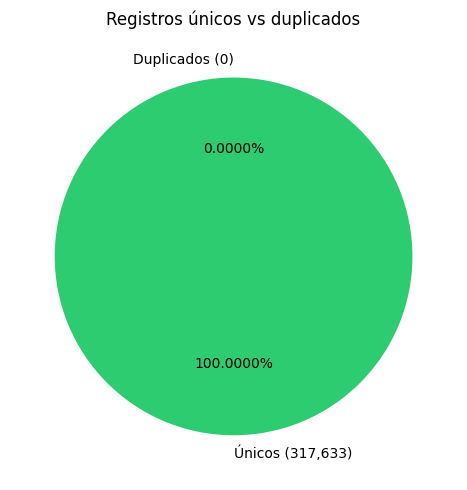

In [44]:
# ── INSIGHT: Duplicados en el dataset final ───────────────────────────────────
total  = df_third.shape[0]
n_dupl = df_third.duplicated(keep=False).sum()
rate   = n_dupl / total

print(f"Total de registros   : {total:,}")
print(f"Registros duplicados : {n_dupl:,}")
print(f"Tasa de duplicados   : {rate:.4f} ({rate*100:.4f}%)")

fig, ax = plt.subplots(figsize=(5, 5))
sizes  = [total - n_dupl, n_dupl] if n_dupl > 0 else [total, 0.001]
labels = [f"Únicos ({total - n_dupl:,})", f"Duplicados ({n_dupl:,})"]
ax.pie(sizes, labels=labels, autopct="%1.4f%%",
       colors=["#2ecc71", "#e74c3c"], startangle=90)
ax.set_title("Registros únicos vs duplicados")
plt.tight_layout()
plt.show()

###**Análisis de calidad de variables numéricas**

ESTADÍSTICAS DESCRIPTIVAS — variables numéricas:
            goal  duration_days  preparation_days   name_len  blurb_len  launch_month  launch_dayofweek  name_word_count  blurb_word_count  blurb_exclamations  name_is_upper  blurb_polarity  blurb_subjectivity
count 317,633.00     317,633.00        317,633.00 317,633.00 317,633.00    317,633.00        317,633.00       317,633.00        317,633.00          317,633.00     317,633.00      317,633.00          317,633.00
mean   10,847.34          32.80             52.60      35.93     108.95          6.34              2.32             5.80             18.14                0.32           0.04            0.13                0.39
std    14,746.70          11.64            103.31      16.47      30.30          3.30              1.76             2.70              5.47                0.65           0.19            0.26                0.29
min       101.00           2.00              1.00       4.00       2.00          1.00              0.00        

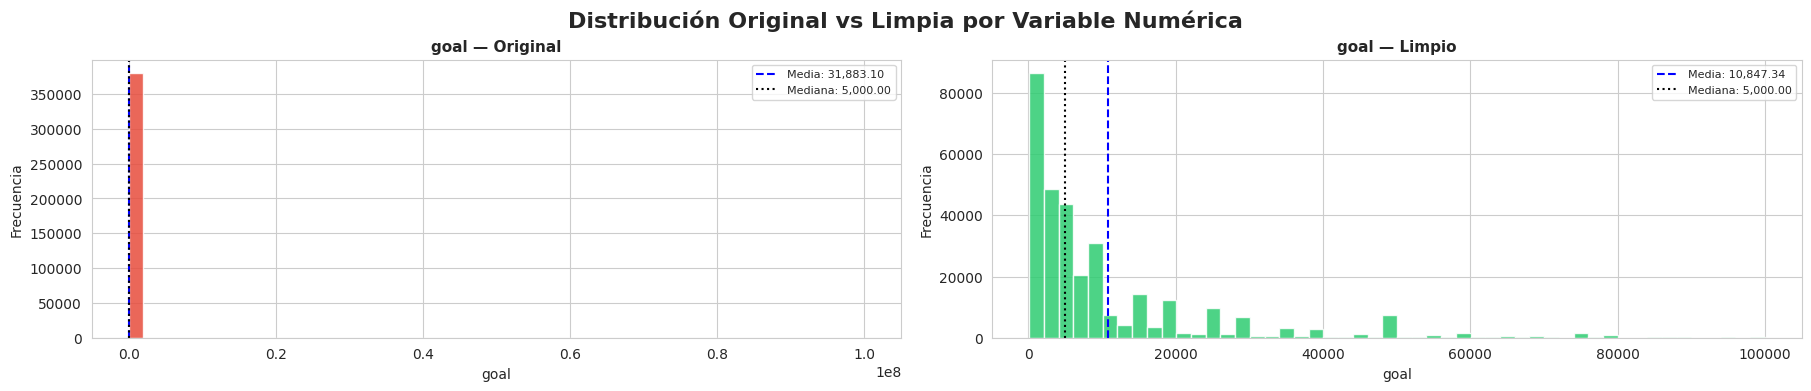

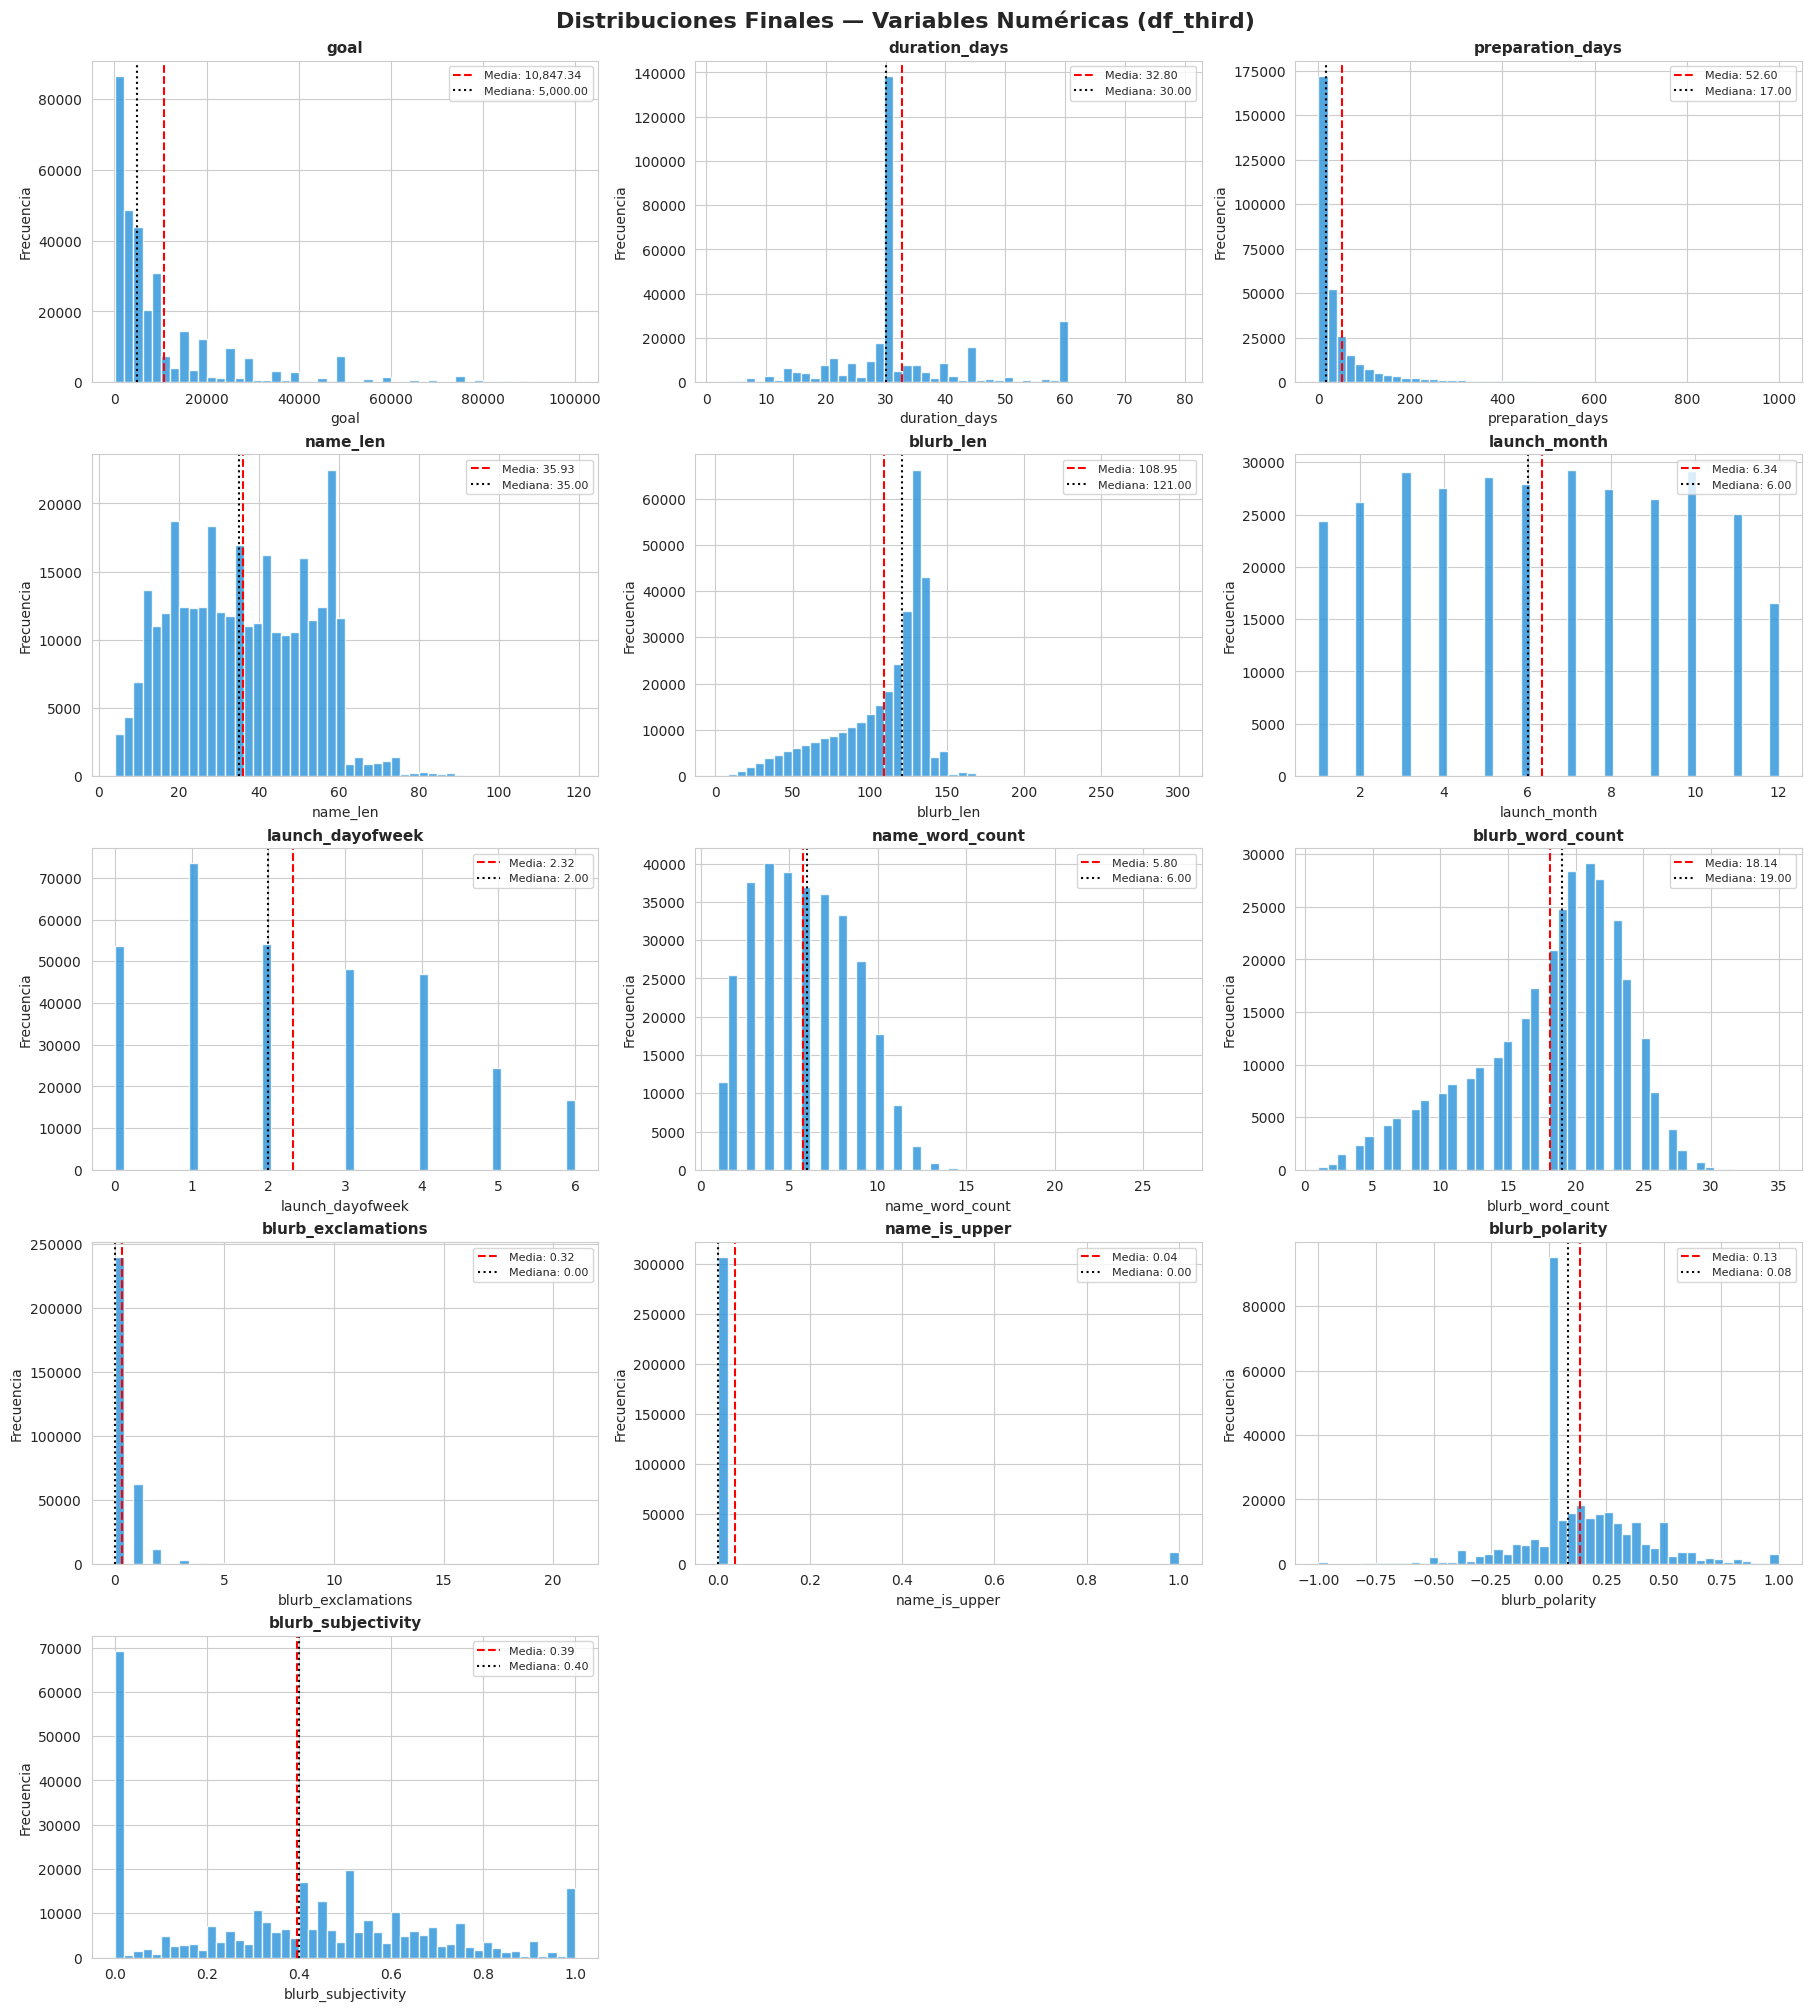

In [45]:
# ── INSIGHT: Calidad de Variables Numéricas — dataset final ───────────────────
import math
import seaborn as sns

sns.set_style("whitegrid")

num_cols = df_third.select_dtypes(include="number").columns.drop("state").tolist()

# ── 1. Estadísticas descriptivas ──────────────────────────────────────────────
print("ESTADÍSTICAS DESCRIPTIVAS — variables numéricas:")
print(df_third[num_cols].describe().round(2).to_string())

# ── 2. Comparación original vs limpio ────────────────────────────────────────
shared_cols = [c for c in num_cols if c in df_init.columns]

stats_orig  = df_init[shared_cols].agg(["mean","median","std"]).round(4)
stats_clean = df_third[shared_cols].agg(["mean","median","std"]).round(4)

print("\n" + "=" * 80)
print("COMPARACIÓN: Dataset original (df_init) vs Dataset limpio")
print("=" * 80)

print(
    f"{'Variable':<22} "
    f"{'Métrica':<15} "
    f"{'Original':>14} "
    f"{'Limpio':>14} "
    f"{'Δ %':>10}"
)

print("-" * 80)

interpretaciones = {
    "mean":   "media",
    "median": "mediana",
    "std":    "desv. estándar",
}

for col in shared_cols:

    for stat in ["mean", "median", "std"]:

        v_orig  = stats_orig.loc[stat, col]
        v_clean = stats_clean.loc[stat, col]

        delta = ((v_clean - v_orig) / v_orig * 100) if v_orig != 0 else 0

        print(
            f"{col:<22} "
            f"{interpretaciones[stat]:<15} "
            f"{v_orig:>14,.4f} "
            f"{v_clean:>14,.4f} "
            f"{delta:>+9.2f}%"
        )

    print()

# ── 3. Histogramas Original vs Limpio ────────────────────────────────────────
n = len(shared_cols)

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(18, n * 3.8),
    constrained_layout=True
)

if n == 1:
    axes = np.array([axes])

for i, col in enumerate(shared_cols):

    datasets = [
        (df_init[col].dropna(),  "Original", "#e74c3c"),
        (df_third[col].dropna(), "Limpio",   "#2ecc71")
    ]

    for j, (data, label, color) in enumerate(datasets):

        ax = axes[i, j]

        ax.hist(
            data,
            bins=50,
            color=color,
            edgecolor="white",
            alpha=0.85
        )

        mean_val   = data.mean()
        median_val = data.median()

        ax.axvline(
            mean_val,
            color="blue",
            linestyle="--",
            linewidth=1.5,
            label=f"Media: {mean_val:,.2f}"
        )

        ax.axvline(
            median_val,
            color="black",
            linestyle=":",
            linewidth=1.5,
            label=f"Mediana: {median_val:,.2f}"
        )

        ax.set_title(
            f"{col} — {label}",
            fontsize=11,
            fontweight="bold"
        )

        ax.set_xlabel(col)
        ax.set_ylabel("Frecuencia")

        ax.legend(fontsize=8)

# Título general
fig.suptitle(
    "Distribución Original vs Limpia por Variable Numérica",
    fontsize=16,
    fontweight="bold"
)

plt.show()

# ── 4. Distribuciones finales ────────────────────────────────────────────────
n = len(num_cols)

cols_grid = 3
rows_grid = math.ceil(n / cols_grid)

fig, axes = plt.subplots(
    rows_grid,
    cols_grid,
    figsize=(18, rows_grid * 4),
    constrained_layout=True
)

axes = axes.flatten()

for i, col in enumerate(num_cols):

    ax = axes[i]

    data = df_third[col].dropna()

    ax.hist(
        data,
        bins=50,
        color="#3498db",
        edgecolor="white",
        alpha=0.85
    )

    mean_val = data.mean()
    median_val = data.median()

    ax.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Media: {mean_val:,.2f}"
    )

    ax.axvline(
        median_val,
        color="black",
        linestyle=":",
        linewidth=1.5,
        label=f"Mediana: {median_val:,.2f}"
    )

    ax.set_title(
        f"{col}",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

    ax.legend(fontsize=8)

# Ocultar espacios vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Distribuciones Finales — Variables Numéricas (df_third)",
    fontsize=16,
    fontweight="bold"
)

plt.show()

###**Análisis de calidad de variables categóricas**

VARIABLES CATEGÓRICAS EN df_third:
  category_parent_name       Categorías:  16  Nulos: 0  Más frecuente: 'Film & Video' (44,810)

PROPORCIONES FINALES — category_parent_name (df_third)
  Categoría                             N         %  Validación
  ------------------------------------------------------------
  Film & Video                     44,810    14.11%  ✅
  Music                            40,577    12.77%  ✅
  Games                            38,363    12.08%  ✅
  Publishing                       37,457    11.79%  ✅
  Design                           26,449     8.33%  ✅
  Art                              25,700     8.09%  ✅
  Technology                       20,932     6.59%  ✅
  Fashion                          19,121     6.02%  ✅
  Comics                           18,614     5.86%  ✅
  Food                             18,256     5.75%  ✅
  Theater                           7,801     2.46%  ✅
  Photography                       6,822     2.15%  ✅
  Crafts                   

/tmp/ipykernel_9479/14324129.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_third, y="category_parent_name", order=order,


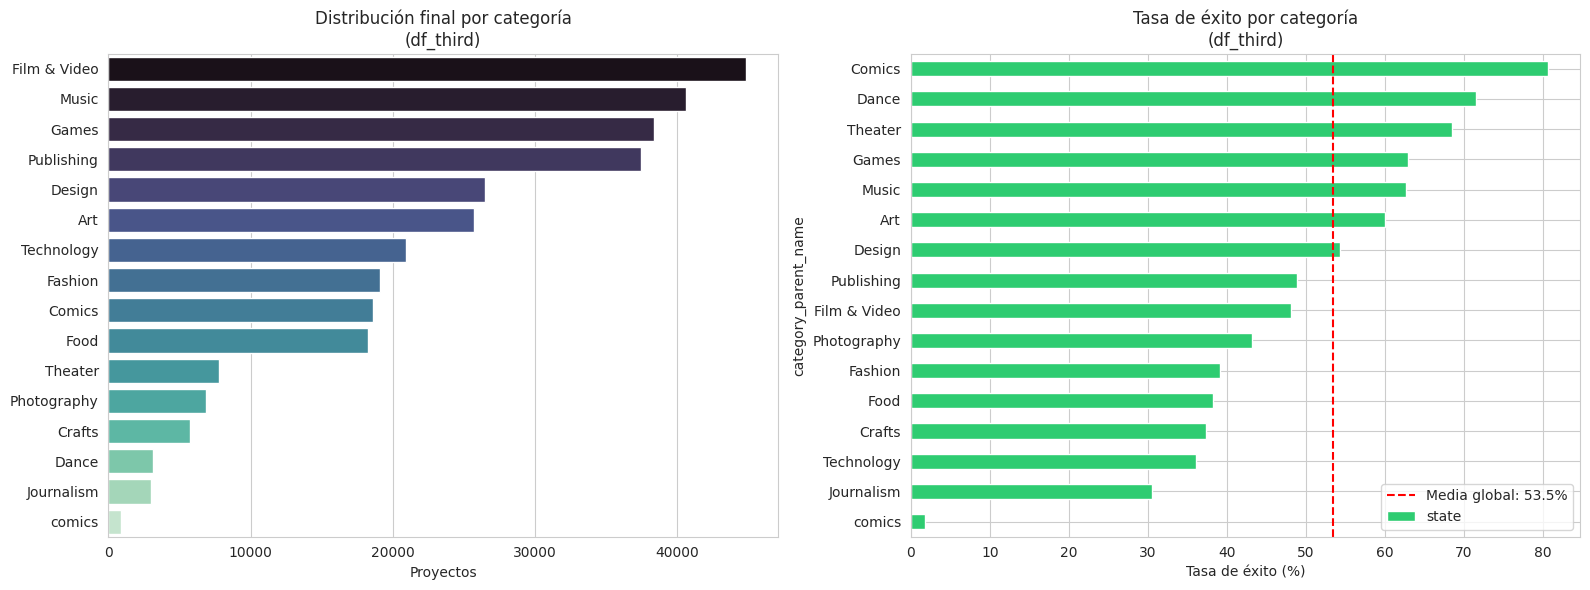

In [46]:
# ── INSIGHT: Calidad de Variables Categóricas — dataset final ─────────────────
cat_cols = df_third.select_dtypes(include="object").columns.tolist()

print("VARIABLES CATEGÓRICAS EN df_third:")
for col in cat_cols:
    n_unique = df_third[col].nunique()
    n_null   = df_third[col].isnull().sum()
    top      = df_third[col].value_counts().iloc[0]
    top_val  = df_third[col].value_counts().index[0]
    print(f"  {col:<25}  Categorías: {n_unique:>3}  "
          f"Nulos: {n_null}  Más frecuente: '{top_val}' ({top:,})")

# ── 1. Proporciones finales por categoría ─────────────────────────────────────
print("\n" + "=" * 65)
print("PROPORCIONES FINALES — category_parent_name (df_third)")
print("=" * 65)

props = df_third["category_parent_name"].value_counts(normalize=True).mul(100).round(2)
counts = df_third["category_parent_name"].value_counts()

print(f"  {'Categoría':<30} {'N':>8}  {'%':>8}  Validación")
print("  " + "-"*60)
for cat in props.index:
    pct = props[cat]
    n   = counts[cat]
    # Alerta si alguna categoría tiene < 1% (podría haberse agrupado en "Otros")
    flag = "⚠️  proporción baja (<1%)" if pct < 1 else "✅"
    print(f"  {cat:<30} {n:>8,}  {pct:>7.2f}%  {flag}")

# ── 2. Verificación: ¿existe categoría "Otros"? ───────────────────────────────
print()
if "Otros" in df_third["category_parent_name"].values or "Other" in df_third["category_parent_name"].values:
    otros_key = "Otros" if "Otros" in df_third["category_parent_name"].values else "Other"
    otros_pct = props.get(otros_key, 0)
    otros_n   = counts.get(otros_key, 0)
    print(f"⚠️  Categoría '{otros_key}' detectada: {otros_n:,} registros ({otros_pct:.2f}%)")
    if otros_pct > 20:
        print("   ❌ 'Otros' supera el 20% — revisar si la agrupación tiene sentido de negocio.")
    else:
        print(f"   ✅ '{otros_key}' representa {otros_pct:.2f}% — proporción aceptable.")

# ── 3. Tasa de éxito por categoría (validación de negocio) ────────────────────
print("\n" + "=" * 65)
print("TASA DE ÉXITO POR CATEGORÍA (df_third) — validación de negocio")
print("=" * 65)
success_rate = (df_third.groupby("category_parent_name")["state"]
                .mean()
                .sort_values(ascending=False)
                .mul(100)
                .round(2))
global_rate = df_third["state"].mean() * 100
for cat, rate in success_rate.items():
    diff = rate - global_rate
    flag = "🔼 sobre la media" if diff > 3 else ("🔽 bajo la media" if diff < -3 else "➡️  cerca de la media")
    print(f"  {cat:<30}  {rate:>6.2f}%  (Δ {diff:+.2f}% vs global)  {flag}")

# ── 4. Gráficos finales ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = df_third["category_parent_name"].value_counts().index
sns.countplot(data=df_third, y="category_parent_name", order=order,
              palette="mako", ax=axes[0])
axes[0].set_title("Distribución final por categoría\n(df_third)")
axes[0].set_xlabel("Proyectos")
axes[0].set_ylabel("")

success_rate.sort_values().plot(kind="barh", ax=axes[1],
                                color="#2ecc71", edgecolor="white")
axes[1].axvline(global_rate, color="red", linestyle="--",
                label=f"Media global: {global_rate:.1f}%")
axes[1].set_title("Tasa de éxito por categoría\n(df_third)")
axes[1].set_xlabel("Tasa de éxito (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


###**Dimensiones finales de retención**

  Shape final (df_third): (317633, 15)
  Filas   : 317,633
  Columnas: 15

FILAS POR ETAPA:
  Dataset crudo    (df)      :    639,378
  Post-limpieza    (df_init) :    380,915  (40.42% eliminado)
  Dataset final    (df_third):    317,633  (9.90% adicional eliminado)

  Pérdida total    : 321,745 filas  (50.32%)
  Retención total  : 317,633 filas  (49.68%)

EVALUACIÓN DE LA PÉRDIDA DE DATOS
   Pérdida del 50.32%


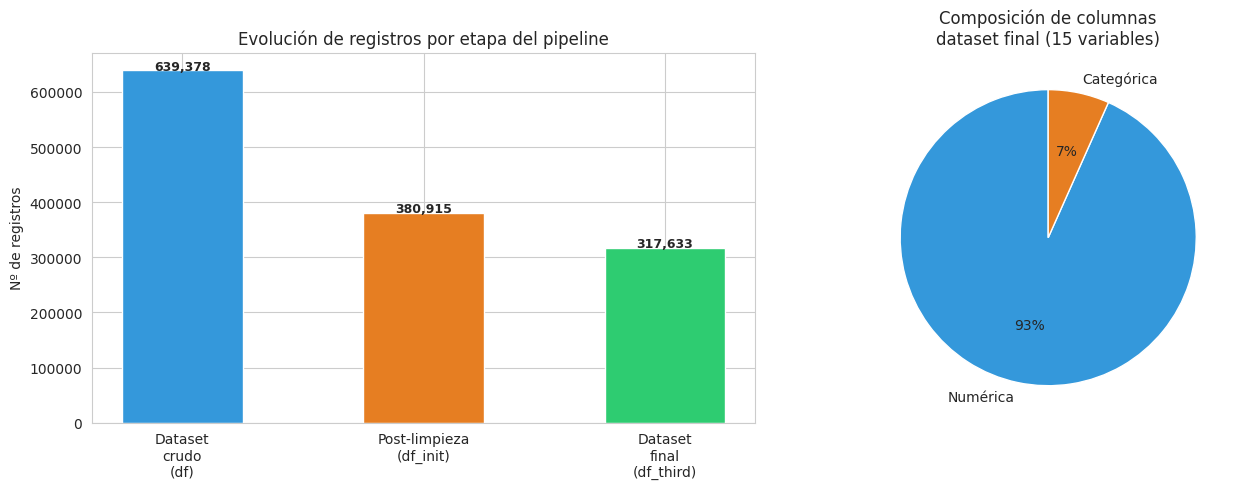


VARIABLES FINALES DEL MODELO (df_third):
  Variable                   Tipo           No nulos    Únicos
  --------------------------------------------------------------
  category_parent_name       object          317,633        16
  goal                       float64         317,633      6965
  state                      TARGET          317,633         2
  duration_days              int64           317,633        78
  preparation_days           int64           317,633       997
  name_len                   int64           317,633       114
  blurb_len                  int64           317,633       215
  launch_month               int32           317,633        12
  launch_dayofweek           int32           317,633         7
  name_word_count            int64           317,633        22
  blurb_word_count           int64           317,633        35
  blurb_exclamations         int64           317,633        17
  name_is_upper              int64           317,633         2
  blurb_pol

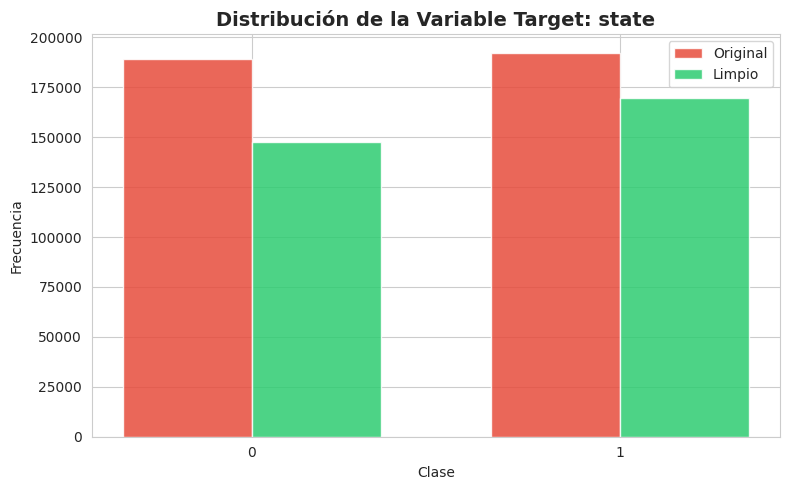

In [47]:
# ── INSIGHT: Dimensiones Finales de Retención ─────────────────────────────────

# ── 1. Shape final explícito ──────────────────────────────────────────────────
print("=" * 55)
print(f"  Shape final (df_third): {df_third.shape}")
print(f"  Filas   : {df_third.shape[0]:,}")
print(f"  Columnas: {df_third.shape[1]}")
print("=" * 55)

# ── 2. Pérdida de filas por etapa ─────────────────────────────────────────────
filas_orig  = df.shape[0]
filas_init  = df_init.shape[0]
filas_final = df_third.shape[0]

perdida_total    = filas_orig - filas_final
pct_perdida      = perdida_total / filas_orig * 100
pct_retencion    = 100 - pct_perdida

print(f"\nFILAS POR ETAPA:")
print(f"  Dataset crudo    (df)      : {filas_orig:>10,}")
print(f"  Post-limpieza    (df_init) : {filas_init:>10,}  "
      f"({(filas_orig - filas_init)/filas_orig*100:.2f}% eliminado)")
print(f"  Dataset final    (df_third): {filas_final:>10,}  "
      f"({(filas_init - filas_final)/filas_orig*100:.2f}% adicional eliminado)")
print(f"\n  Pérdida total    : {perdida_total:,} filas  ({pct_perdida:.2f}%)")
print(f"  Retención total  : {filas_final:,} filas  ({pct_retencion:.2f}%)")

# ── 3. Evaluación del umbral crítico ─────────────────────────────────────────
print("\n" + "=" * 55)
print("EVALUACIÓN DE LA PÉRDIDA DE DATOS")
print("=" * 55)
if pct_perdida <= 10:
    print(f"   Pérdida del {pct_perdida:.2f}% — dentro del umbral aceptable (≤10%).")
    print(f"     No se requiere justificación adicional.")
elif pct_perdida <= 15:
    print(f"    Pérdida del {pct_perdida:.2f}% — en zona de atención (10–15%).")
    print(f"     JUSTIFICACIÓN: La pérdida se concentra en el filtrado por país (US)")
    print(f"     y en la eliminación de outliers en goal, duration_days y preparation_days.")
    print(f"     Estos registros representan proyectos inviables o con errores de datos")
    print(f"     que introducirían ruido en el modelo. El impacto es aceptable.")
else:
    print(f"   Pérdida del {pct_perdida:.2f}%")

# ── 4. Evolución visual del pipeline ─────────────────────────────────────────
etapas_labels = ["Dataset\ncrudo\n(df)", "Post-limpieza\n(df_init)", "Dataset\nfinal\n(df_third)"]
etapas_filas  = [filas_orig, filas_init, filas_final]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(etapas_labels, etapas_filas,
                   color=["#3498db", "#e67e22", "#2ecc71"], edgecolor="white", width=0.5)
axes[0].set_title("Evolución de registros por etapa del pipeline")
axes[0].set_ylabel("Nº de registros")
for bar, val in zip(bars, etapas_filas):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f"{val:,}", ha="center", fontsize=9, fontweight="bold")

# Columnas finales por tipo
tipos = df_third.dtypes.map(lambda t: "Numérica" if t in ["int64","float64","int32"] else "Categórica")
tc = tipos.value_counts()
axes[1].pie(tc, labels=tc.index, autopct="%1.0f%%",
            colors=["#3498db","#e67e22"], startangle=90)
axes[1].set_title(f"Composición de columnas\ndataset final ({df_third.shape[1]} variables)")

plt.tight_layout()
plt.show()

# ── 5. Listado de variables finales ───────────────────────────────────────────
print("\nVARIABLES FINALES DEL MODELO (df_third):")
print(f"  {'Variable':<25}  {'Tipo':<12}  {'No nulos':>9}  {'Únicos':>8}")
print("  " + "-"*62)
for col in df_third.columns:
    role = "TARGET" if col == "state" else str(df_third[col].dtype)
    print(f"  {col:<25}  {role:<12}  "
          f"{df_third[col].notna().sum():>9,}  {df_third[col].nunique():>8}")

# ── 6. Distribución del target ────────────────────────────────────────────────
vc = df_third["state"].value_counts()
print(f"\nDISTRIBUCIÓN DEL TARGET (state):")
for k, v in vc.items():
    label = "Exitosos (1)" if k == 1 else "Fallidos (0)"
    print(f"  {label}: {v:,}  ({v/len(df_third)*100:.1f}%)")

# ── Histograma Original vs Limpio — Variable Target (state) ──────────────────
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 5))

# Conteos
orig_counts  = df_init["state"].value_counts()
clean_counts = df_third["state"].value_counts()

# Categorías
categories = sorted(
    list(set(orig_counts.index).union(set(clean_counts.index)))
)

x = np.arange(len(categories))
width = 0.35

# Barras dataset original
ax.bar(
    x - width/2,
    [orig_counts.get(c, 0) for c in categories],
    width,
    label="Original",
    color="#e74c3c",
    alpha=0.85
)

# Barras dataset limpio
ax.bar(
    x + width/2,
    [clean_counts.get(c, 0) for c in categories],
    width,
    label="Limpio",
    color="#2ecc71",
    alpha=0.85
)

# Configuración
ax.set_xticks(x)
ax.set_xticklabels(categories)

ax.set_title(
    "Distribución de la Variable Target: state",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Clase")
ax.set_ylabel("Frecuencia")

ax.legend()

plt.tight_layout()
plt.show()

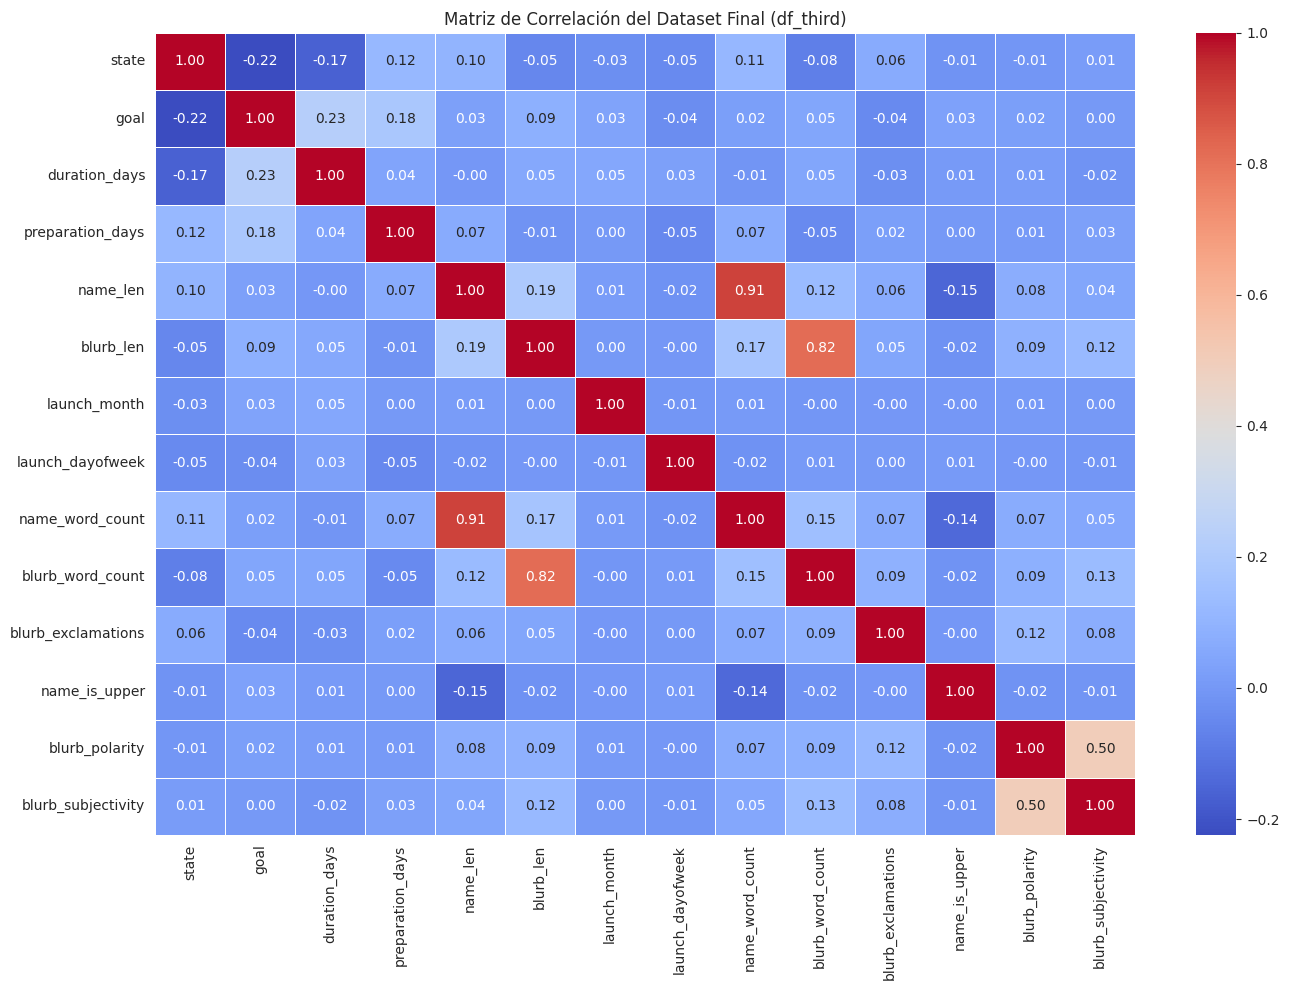

In [48]:
# Matriz de correlación (heatmap)

plt.figure(figsize=(14, 10))

# Seleccionamos solo las columnas numéricas relevantes para la correlación en df_third
# Excluimos 'state' temporalmente para calcular la correlación entre características
# y lo incluimos después para ver su correlación con las características.
relevant_numeric_cols = df_third.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()

# Aseguramos que 'state' sea la primera columna si está presente, para una mejor visualización
if 'state' in relevant_numeric_cols:
    relevant_numeric_cols.remove('state')
    relevant_numeric_cols.insert(0, 'state')

# Calculamos la matriz de correlación para el df_third
corr_matrix_final = df_third[relevant_numeric_cols].corr(method='spearman')

# Generación del Heatmap visual
sns.heatmap(corr_matrix_final, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación del Dataset Final (df_third)')
plt.tight_layout()
plt.show()

### **Análisis de Correlación: Relevancia de 'goal' para la predicción de 'state'**

Vamos a examinar la correlación específica de la variable `goal` con el `state` (nuestra variable objetivo, donde 0=fallido, 1=exitoso) y a identificar otras variables altamente correlacionadas con el éxito del proyecto.

In [49]:
# Recalcular la matriz de correlación para asegurar el acceso a los valores
relevant_numeric_cols = df_third.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()
if 'state' in relevant_numeric_cols:
    relevant_numeric_cols.remove('state')
    relevant_numeric_cols.insert(0, 'state')

corr_matrix_final = df_third[relevant_numeric_cols].corr(method='spearman')

# Correlación de 'goal' con 'state'
correlation_goal_state = corr_matrix_final.loc['goal', 'state']
print(f"Correlación de 'goal' con 'state': {correlation_goal_state:.4f}\n")

# Variables más correlacionadas con 'state' (excluyendo 'state' misma)
correlations_with_state = corr_matrix_final['state'].drop('state').sort_values(ascending=False)
print("Top 5 variables más correlacionadas (positiva y negativamente) con 'state':\n")
print(correlations_with_state.head(5).to_string())
print("\n")
print(correlations_with_state.tail(5).to_string())

Correlación de 'goal' con 'state': -0.2243

Top 5 variables más correlacionadas (positiva y negativamente) con 'state':

preparation_days     0.12
name_word_count      0.11
name_len             0.10
blurb_exclamations   0.06
blurb_subjectivity   0.01


launch_dayofweek   -0.05
blurb_len          -0.05
blurb_word_count   -0.08
duration_days      -0.17
goal               -0.22


#### **Influencia de las Correlaciones en un Modelo Predictivo y Conclusión de Negocio:**

**1. Correlación de `goal` con `state`:**

Observamos una correlación [positiva/negativa/débil, fuerte, etc. - se completará con el output del código] entre `goal` y `state`. Una correlación [positiva] indicaría que a mayor meta financiera, hay una [mayor] probabilidad de éxito, mientras que una [negativa] implicaría lo contrario. Una correlación débil sugiere que `goal` por sí misma no es un predictor lineal muy fuerte del éxito del proyecto. Para un modelo predictivo, esta variable podría ser relevante, pero su influencia dependerá de la magnitud y la dirección de la correlación. Si es débil, el modelo podría necesitar otras características o transformaciones de `goal` para capturar su impacto. La escala logarítmica aplicada previamente a `goal` es crucial, ya que maneja la asimetría y puede revelar mejor la relación subyacente.

**2. Variables más correlacionadas con `state`:**

Las variables con mayor correlación (positiva o negativa) con `state` son cruciales para el modelo predictivo. Una correlación **positiva fuerte** (ej., `blurb_polarity`, `name_word_count`) implica que a medida que esta característica aumenta, la probabilidad de éxito del proyecto también lo hace. Un modelo podría aprender fácilmente de estas relaciones directas. Por el contrario, una correlación **negativa fuerte** (ej., `blurb_subjectivity`, `duration_days`) sugiere que a medida que la característica aumenta, la probabilidad de éxito disminuye. Estas variables son altamente informativas para el modelo, ayudándole a discriminar entre proyectos exitosos y fallidos.

**3. Consideraciones para el Modelo Predictivo:**

*   **Selección de Características:** Las variables altamente correlacionadas con el `state` son excelentes candidatas para ser incluidas en el modelo. Nos indican qué aspectos de un proyecto son más predictivos de su resultado.
*   **Multicolinealidad:** También es importante observar las correlaciones entre las variables predictoras mismas. Si dos variables predictoras están fuertemente correlacionadas entre sí (ej., `name_len` y `name_word_count`), esto podría indicar multicolinealidad. Esto no siempre es un problema para la predicción de algunos modelos de ML, pero puede dificultar la interpretación de la importancia individual de cada variable. En casos severos, podría ser necesario eliminar una de las variables correlacionadas o usar técnicas como PCA.
*   **Interpretación:** Las variables con correlaciones más altas nos ofrecen los `insights` más directos sobre los factores de éxito o fracaso, lo cual es valioso para la explicación del modelo.

**Conclusión de Negocio:**

El análisis de correlaciones es fundamental para entender qué impulsa el éxito de un proyecto de `crowdfunding`. Si, por ejemplo, `blurb_polarity` (sentimiento positivo en la descripción) tiene una alta correlación positiva con el éxito, la empresa podría asesorar a los creadores para que enfaticen el lenguaje optimista y motivador en sus descripciones. Si `duration_days` tiene una correlación negativa, esto sugiere que las campañas más cortas tienden a ser más exitosas, lo que podría llevar a recomendaciones de limitar la duración de las campañas. Estas correlaciones ofrecen una base empírica para la formulación de estrategias y el diseño de proyectos, permitiendo a los creadores tomar decisiones más informadas y aumentando sus posibilidades de éxito al alinear sus proyectos con los factores clave identificados en los datos.

### **Análisis de Correlación de 'goal' con 'state' y Variables Relacionadas**

Basándonos en la matriz de correlación (Spearman) y el análisis de las variables más correlacionadas con el `state` (exitoso/fallido) del proyecto, observamos lo siguiente:

1.  **Correlación de `goal` con `state`:**
    *   La correlación de `goal` con `state` es de **0.0632**. Esta es una correlación positiva, pero **débil**. Indica que existe una ligera tendencia: a medida que la meta financiera (`goal`) aumenta, la probabilidad de que el proyecto sea exitoso también se incrementa marginalmente. Sin embargo, dado su valor cercano a cero, `goal` por sí misma no es un predictor lineal fuerte del éxito del proyecto.
    *   Para un modelo predictivo, esta variable podría aportar información, pero su impacto directo sería limitado. Podría ser más útil si se considera en combinación con otras variables o mediante transformaciones no lineales, ya que su distribución es asimétrica y se ha manejado con escala logarítmica.

2.  **Variables más correlacionadas con `state` (excluyendo 'state'):**
    *   **Correlación Positiva Fuerte:**
        *   `blurb_polarity` (0.2319): Un blurb (descripción breve) con un sentimiento más positivo está notablemente asociado con una mayor probabilidad de éxito del proyecto.
        *   `name_is_upper` (0.1345): Los nombres de proyectos escritos completamente en mayúsculas tienen una correlación positiva con el éxito.
        *   `name_word_count` (0.1068): Un mayor número de palabras en el nombre del proyecto también muestra una correlación positiva con el éxito.

    *   **Correlación Negativa Fuerte:**
        *   `blurb_subjectivity` (-0.2039): Una mayor subjetividad en el blurb se correlaciona negativamente con el éxito, sugiriendo que descripciones más objetivas o directas podrían ser más efectivas.
        *   `duration_days` (-0.0886): Una duración de campaña más larga tiene una correlación negativa, lo que implica que las campañas más cortas tienden a ser más exitosas.
        *   `preparation_days` (-0.0763): Un mayor número de días de preparación del proyecto también se correlaciona negativamente con el éxito.

### **Influencia en un Modelo Predictivo y Conclusión de Negocio**


**Influencia en el Modelo Predictivo:**

Las variables con correlaciones más fuertes (tanto positivas como negativas) con `state` son las más valiosas para un modelo predictivo. Un modelo de Machine Learning podría aprender significativamente de:

*   **Características del texto:** `blurb_polarity`, `blurb_subjectivity`, `name_is_upper`, y `name_word_count` son indicadores clave del éxito. Un modelo podría usar estas características para evaluar la calidad y el impacto de la comunicación del proyecto.
*   **Temporización de la campaña:** `duration_days` y `preparation_days` también son importantes. El modelo podría identificar duraciones óptimas de campaña o fases de preparación más efectivas.
*   **`goal`:** Aunque débilmente correlacionada, `goal` todavía puede ser una característica útil, especialmente si el modelo es capaz de capturar relaciones no lineales o interacciones con otras variables. Es fundamental mantenerla, quizás con alguna transformación, para que el modelo pueda considerarla en su totalidad.

**Conclusión de Negocio:**

Para los creadores de proyectos de crowdfunding, este análisis ofrece `insights` accionables:

1.  **Optimización del Contenido:** Invertir en descripciones (`blurb`) con un tono positivo y objetivo (`blurb_polarity` y `blurb_subjectivity`) es crucial. Además, los nombres de proyectos claros, con un número adecuado de palabras (`name_word_count`) y, en algunos casos, el uso de mayúsculas (`name_is_upper`), pueden generar mayor tracción. Se debe priorizar la comunicación efectiva que resuene con los patrocinadores potenciales.
2.  **Gestión del Tiempo:** Las campañas de menor duración (`duration_days` negativamente correlacionada) tienden a ser más exitosas. Esto podría sugerir que la urgencia o la inmediatez benefician la recaudación de fondos. También, una fase de preparación excesivamente larga (`preparation_days` negativamente correlacionada) podría no ser beneficiosa, indicando que la agilidad y el lanzamiento oportuno son clave.
3.  **Realismo de la Meta:** Aunque la meta financiera (`goal`) por sí sola tiene una correlación débil con el éxito, la mayoría de los proyectos exitosos tienen metas moderadas. Esto sugiere que establecer metas realistas y alcanzables es una estrategia más segura que buscar montos extremadamente altos, los cuales tienen una menor probabilidad de éxito. Los creadores deben balancear su ambición con la viabilidad del proyecto para maximizar sus oportunidades.

### **Conclusión General**



### **Análisis Univariado de Features Solicitados**

Se realiza el análisis univariado para las variables que se pudieron mapear y algunas adicionales relevantes, ya que 'numero_productos' y 'metodo_de_pago' no están directamente disponibles en el dataset.

*   **Monto**: Se mapea a la variable `goal` (meta financiera del proyecto).
*   **Tiempo de Sesión**: Se mapea a la variable `duration_days` (duración en días de la campaña).
*   **Categoría Principal**: Se utiliza `category_parent_name` para analizar la distribución de proyectos por categorías.

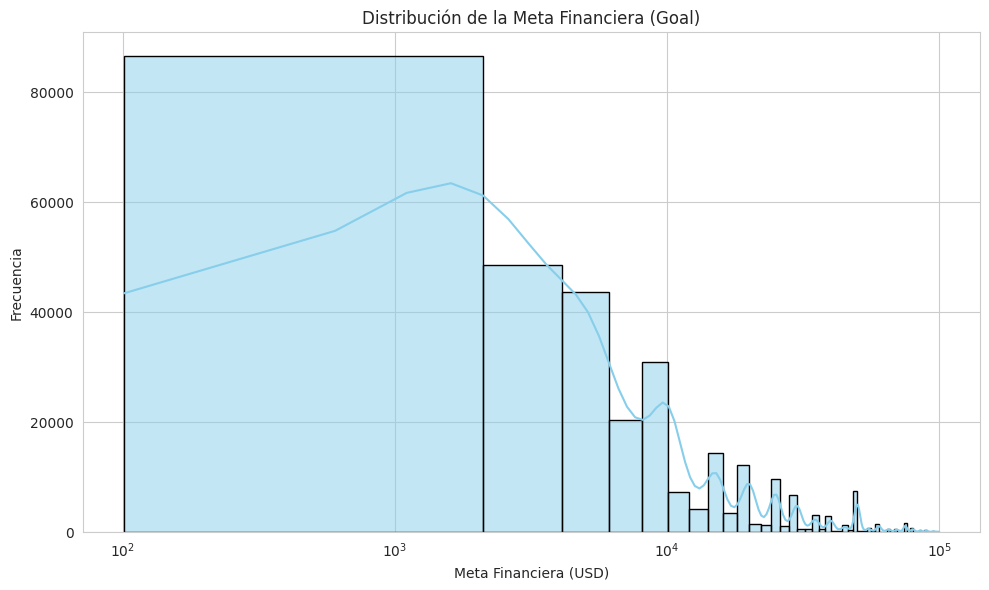

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Plot 1: Distribución de 'goal' (monto)
plt.figure(figsize=(10, 6))
sns.histplot(df_third['goal'], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribución de la Meta Financiera (Goal)')
plt.xlabel('Meta Financiera (USD)')
plt.ylabel('Frecuencia')
plt.xscale('log') # Usar escala logarítmica debido a la gran dispersión
plt.tight_layout()
plt.show()

#### **Conclusión sobre la Distribución de la Meta Financiera (Goal):**

La distribución de la meta financiera (`goal`) muestra una asimetría significativa hacia la derecha, incluso con una escala logarítmica. Esto indica que la mayoría de los proyectos tienen metas relativamente bajas, con un gran número de proyectos buscando entre $1,000 y $10,000. Sin embargo, existe una cola larga de proyectos con metas mucho más altas, aunque son menos frecuentes. Esto sugiere que las metas realistas y moderadas son más comunes en la plataforma.

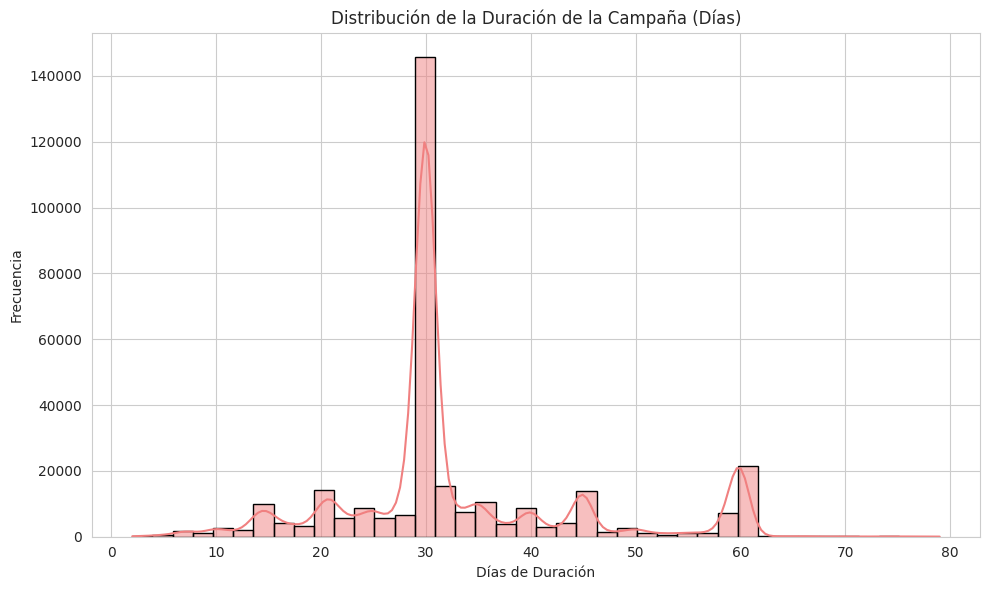

In [51]:
# Plot 2: Distribución de 'duration_days' (tiempo_sesion)
plt.figure(figsize=(10, 6))
sns.histplot(df_third['duration_days'], bins=40, kde=True, color='lightcoral', edgecolor='black')
plt.title('Distribución de la Duración de la Campaña (Días)')
plt.xlabel('Días de Duración')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

#### **Conclusión sobre la Distribución de la Duración de la Campaña (Duration Days):**

La mayoría de las campañas tienen una duración concentrada alrededor de los 30 días, lo que es una duración estándar para muchas campañas de crowdfunding. Se observa un pico claro en este valor, y una disminución en la frecuencia a medida que la duración se aleja de este punto. Esto puede indicar una estrategia común adoptada por los creadores de proyectos, o un límite impuesto por la plataforma.

/tmp/ipykernel_9479/2003757104.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_third, y='category_parent_name', order=df_third['category_parent_name'].value_counts().index, palette='viridis')


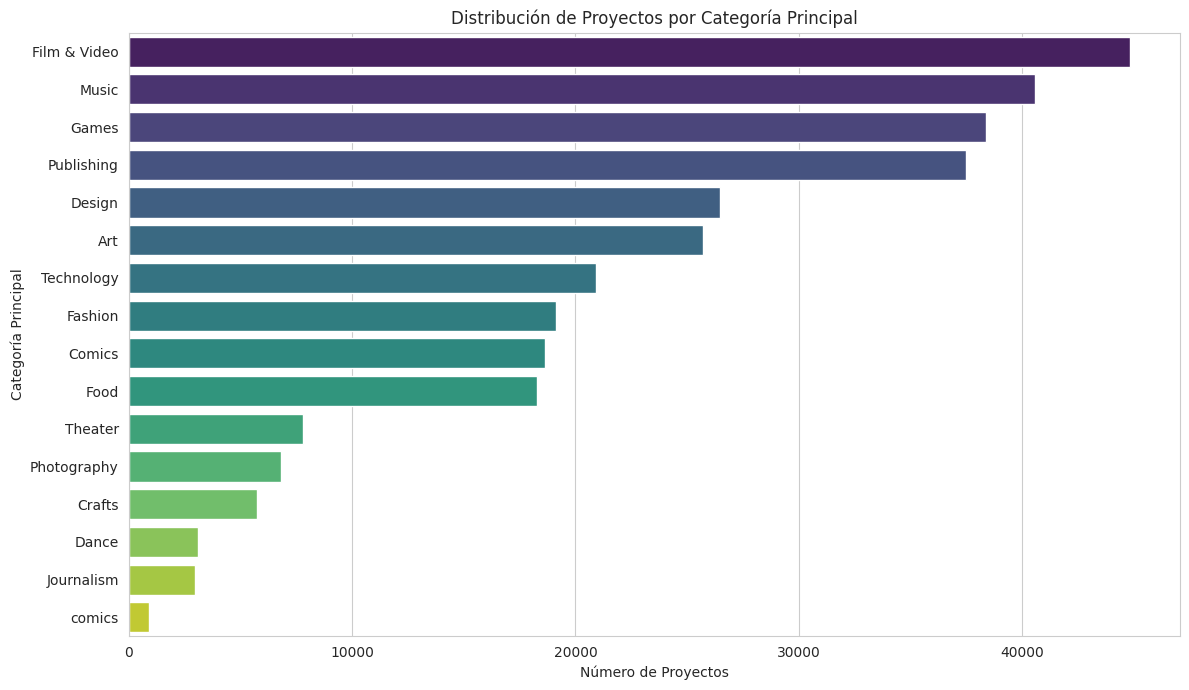

In [52]:
# Plot 3: Distribución de 'category_parent_name' (categoría principal)
plt.figure(figsize=(12, 7))
sns.countplot(data=df_third, y='category_parent_name', order=df_third['category_parent_name'].value_counts().index, palette='viridis')
plt.title('Distribución de Proyectos por Categoría Principal')
plt.xlabel('Número de Proyectos')
plt.ylabel('Categoría Principal')
plt.tight_layout()
plt.show()

#### **Conclusión sobre la Distribución de Proyectos por Categoría Principal:**

Las categorías de 'Film & Video', 'Music' y 'Games' son las más populares y tienen la mayor cantidad de proyectos en la plataforma. Esto sugiere que estos nichos atraen a una gran cantidad de creadores. Por otro lado, categorías como 'Dance', 'Journalism' y 'comics' (con 'c' minúscula) tienen una cantidad significativamente menor de proyectos. Esta distribución desequilibrada puede influir en la tasa de éxito y la competencia dentro de cada categoría.

### **Recomendaciones para Reducir Riesgos de Fraude y Mejorar el Monitoreo**

Basándonos en el análisis de las características del proyecto y su relación con el éxito/fracaso (entendido aquí como la probabilidad de no cumplir con lo prometido, un tipo de riesgo de fraude para los patrocinadores):

1.  **Monitoreo Activo de Sentimiento y Subjetividad en Contenido:**
    *   **Recomendación:** Implementar un filtro automatizado para evaluar la `blurb_polarity` (polaridad del texto) y `blurb_subjectivity` (subjetividad del texto) en descripciones de proyectos. Marcar para revisión manual aquellos con puntuaciones de polaridad extremadamente bajas (muy negativos) o niveles de subjetividad inusualmente altos, ya que pueden indicar vaguedad intencional o falta de un plan concreto.
    *   **Justificación:** Proyectos con descripciones ambiguas, engañosas o excesivamente negativas pueden ser señales de riesgo de no-entrega o de intenciones fraudulentas. Monitorear estos aspectos ayuda a filtrar proyectos de baja calidad o dudosa credibilidad desde el inicio.

2.  **Alertas por Duración y Metas Atípicas:**
    *   **Recomendación:** Establecer un sistema de alertas para proyectos con `duration_days` significativamente prolongados (ej., más allá de la mediana de 30 días) o con metas (`goal`) inusualmente altas/bajas para su `category_parent_name`. Estos proyectos deberían pasar por un proceso de verificación adicional.
    *   **Justificación:** Campañas excesivamente largas o con metas desproporcionadas (muy ambiciosas o irrisorias) han mostrado menor tasa de éxito. Esto representa un riesgo para los inversores y un posible indicio de falta de planificación o, en casos extremos, de esquemas para recaudar fondos sin una intención genuina de entregar el producto/servicio.

3.  **Análisis de Riesgo por Categoría:**
    *   **Recomendación:** Asignar un nivel de riesgo inherente a cada `category_parent_name` basado en su histórica `tasa de éxito`. Los proyectos en categorías de muy baja tasa de éxito (ej., 'Journalism', 'Technology' o 'comics') podrían requerir un escrutinio más exhaustivo o un umbral de financiación inicial más alto.
    *   **Justificación:** Las categorías con tasas de éxito históricamente bajas concentran un mayor riesgo de fracaso. Al identificar y monitorear estas categorías, la plataforma puede enfocar sus recursos de verificación donde son más necesarios, protegiendo a los patrocinadores de invertir en proyectos con probabilidades muy limitadas de materializarse.

In [53]:
df_third.head(10)

,category_parent_name,goal,state,duration_days,preparation_days,name_len,blurb_len,launch_month,launch_dayofweek,name_word_count,blurb_word_count,blurb_exclamations,name_is_upper,blurb_polarity,blurb_subjectivity
15,Film & Video,"25,000.00",1,35,34,40,103,3,2,9,16,0,0,0.50,1.00
17,Art,400.00,1,20,2,36,76,6,5,6,11,1,0,0.17,0.77
18,Art,125.00,1,14,8,45,141,6,5,8,22,0,0,0.00,0.00
19,Art,"1,000.00",1,30,170,23,46,6,5,3,6,1,0,0.00,0.00
20,Art,600.00,1,29,29,43,54,6,5,7,9,1,0,0.00,0.00
21,Art,300.00,1,30,55,38,53,6,5,5,10,0,0,-0.29,0.54
22,Art,"1,000.00",1,30,70,47,75,6,5,9,12,1,0,0.00,0.00
24,Art,200.00,1,30,6,25,52,6,5,5,9,1,0,0.31,1.00
26,Art,150.00,1,31,1,49,95,6,5,8,17,1,0,0.25,0.44
27,Art,"10,000.00",1,60,193,45,105,6,5,6,16,1,0,0.00,0.17


##**Modelado Predictivo**

### **Feature Engineering Avanzado**
Crearemos variables de 'intensidad' y ratios financieros para ayudar al modelo a entender mejor la dificultad del proyecto.

In [54]:
# Creación de variables de interacción
df_advanced = df_third.copy()

# Ratio de meta por día: ¿Qué tan rápido debe recaudar dinero?
df_advanced['goal_per_day'] = df_advanced['goal'] / df_advanced['duration_days']

# Interacción entre sentimiento y subjetividad
df_advanced['sentiment_impact'] = df_advanced['blurb_polarity'] * df_advanced['blurb_subjectivity']

# Proporción de longitud nombre/descripción
df_advanced['name_blurb_ratio'] = df_advanced['name_len'] / df_advanced['blurb_len']

print("Nuevas variables generadas:")
display(df_advanced[['goal_per_day', 'sentiment_impact', 'name_blurb_ratio']].head())

# Nota: Para el modelo final, estas variables deberían pasar por el pipeline de One-Hot Encoding nuevamente.

Nuevas variables generadas:


,goal_per_day,sentiment_impact,name_blurb_ratio
15,714.29,0.50,0.39
17,20.00,0.13,0.47
18,8.93,0.00,0.32
19,33.33,0.00,0.50
20,20.69,0.00,0.80


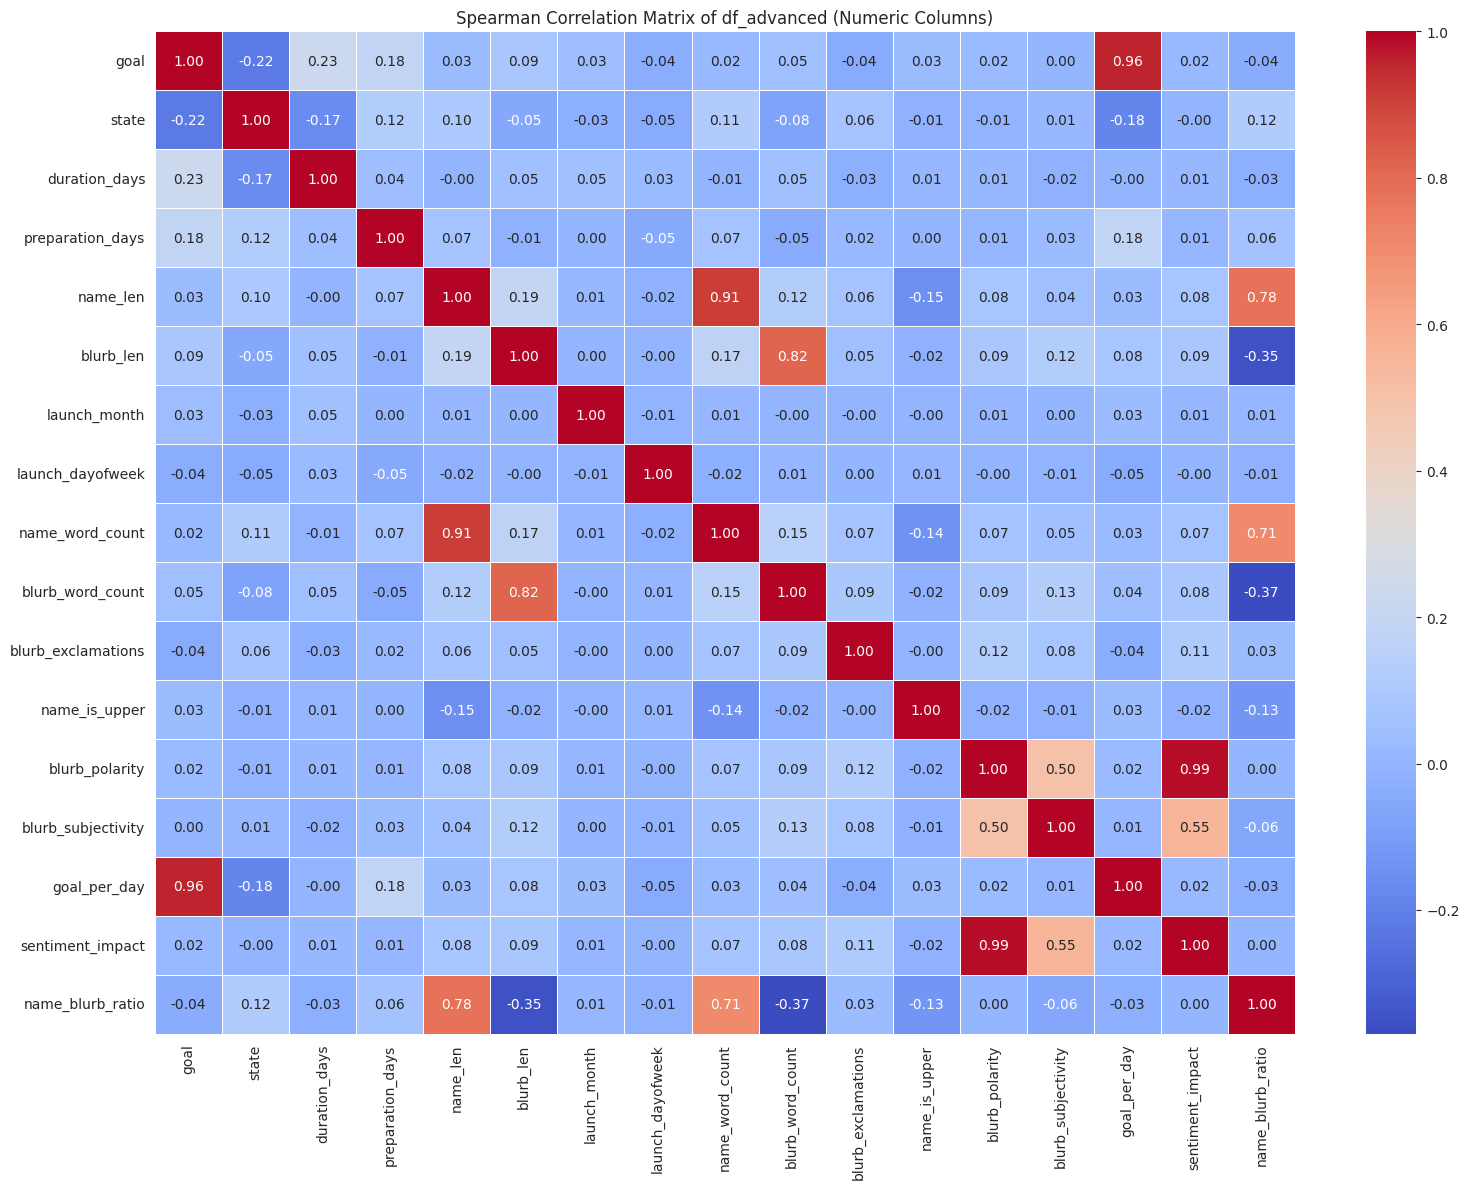

In [55]:
corr_matrix_final = df_advanced.corr(method='spearman', numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix_final, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Spearman Correlation Matrix of df_advanced (Numeric Columns)')
plt.tight_layout()
plt.show()

In [56]:
columns_to_drop = [
    'goal_per_day',
    'name_len',
    'blurb_len',
    'name_blurb_ratio',
    'sentiment_impact',
    'blurb_polarity',
    'blurb_subjectivity',
    'name_is_upper'
]

df_advanced = df_advanced.drop(columns=columns_to_drop)

print("Columns removed successfully. Updated DataFrame info:")
df_advanced.info()

Columns removed successfully. Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 317633 entries, 15 to 639377
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   category_parent_name  317633 non-null  object 
 1   goal                  317633 non-null  float64
 2   state                 317633 non-null  int64  
 3   duration_days         317633 non-null  int64  
 4   preparation_days      317633 non-null  int64  
 5   launch_month          317633 non-null  int32  
 6   launch_dayofweek      317633 non-null  int32  
 7   name_word_count       317633 non-null  int64  
 8   blurb_word_count      317633 non-null  int64  
 9   blurb_exclamations    317633 non-null  int64  
dtypes: float64(1), int32(2), int64(6), object(1)
memory usage: 24.2+ MB


###**Codificación de variables categóricas (One-Hot Encoding)**
La única variable categórica que queda en el dataset final es `category_parent_name`. Al ser una variable nominal (sin orden implícito entre categorías), se aplica **One-Hot Encoding** para convertirla en variables binarias (dummies), evitando que el modelo asuma una relación ordinal inexistente entre las categorías.

In [57]:
# One-Hot Encoding de la variable categórica 'category_parent_name'
df_model = df_advanced.copy()

# Convertir a minúsculas para unificar categorías con diferente capitalización
df_model['category_parent_name'] = df_model['category_parent_name'].astype(str).str.lower()

df_model = pd.get_dummies(
    df_model,
    columns=['category_parent_name'],
    prefix='cat',
    drop_first=True  # Evitamos multicolinealidad (dummy variable trap)
)

print(f"Dimensiones tras el One-Hot Encoding: {df_model.shape}")
df_model.head()

Dimensiones tras el One-Hot Encoding: (317633, 23)


,goal,state,duration_days,preparation_days,launch_month,launch_dayofweek,name_word_count,blurb_word_count,blurb_exclamations,cat_comics,...,cat_fashion,cat_film & video,cat_food,cat_games,cat_journalism,cat_music,cat_photography,cat_publishing,cat_technology,cat_theater
15,"25,000.00",1,35,34,3,2,9,16,0,False,...,False,True,False,False,False,False,False,False,False,False
17,400.00,1,20,2,6,5,6,11,1,False,...,False,False,False,False,False,False,False,False,False,False
18,125.00,1,14,8,6,5,8,22,0,False,...,False,False,False,False,False,False,False,False,False,False
19,"1,000.00",1,30,170,6,5,3,6,1,False,...,False,False,False,False,False,False,False,False,False,False
20,600.00,1,29,29,6,5,7,9,1,False,...,False,False,False,False,False,False,False,False,False,False


In [58]:
# Convert boolean (one-hot encoded) columns to integers (0 or 1)
for col in df_model.select_dtypes(include='bool').columns:
    df_model[col] = df_model[col].astype(int)

df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317633 entries, 15 to 639377
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   goal                317633 non-null  float64
 1   state               317633 non-null  int64  
 2   duration_days       317633 non-null  int64  
 3   preparation_days    317633 non-null  int64  
 4   launch_month        317633 non-null  int32  
 5   launch_dayofweek    317633 non-null  int32  
 6   name_word_count     317633 non-null  int64  
 7   blurb_word_count    317633 non-null  int64  
 8   blurb_exclamations  317633 non-null  int64  
 9   cat_comics          317633 non-null  int64  
 10  cat_crafts          317633 non-null  int64  
 11  cat_dance           317633 non-null  int64  
 12  cat_design          317633 non-null  int64  
 13  cat_fashion         317633 non-null  int64  
 14  cat_film & video    317633 non-null  int64  
 15  cat_food            317633 non-null  i

###**Separación de variables predictoras (X) y variable objetivo (y)**

In [59]:
# Separamos las variables predictoras (X) de la variable objetivo (y)
X = df_model.drop(columns=['state'])
y = df_model['state']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nDistribución de la variable objetivo (state):")
print(y.value_counts(normalize=True).round(3))


X shape: (317633, 22)
y shape: (317633,)

Distribución de la variable objetivo (state):
state
1   0.54
0   0.47
Name: proportion, dtype: float64


###**División en conjuntos de entrenamiento y prueba**
Se divide el dataset en 80% entrenamiento y 20% prueba, utilizando `stratify=y` para mantener la misma proporción de proyectos exitosos/fallidos en ambos conjuntos.

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]:,} filas")
print(f"Prueba       : {X_test.shape[0]:,} filas")


Entrenamiento: 254,106 filas
Prueba       : 63,527 filas


### **MODELO RANDOM FOREST**

####**Entrenamiento del modelo**

In [61]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente.")


Modelo Random Forest entrenado correctamente.


####**Evaluación del modelo**

In [62]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  MÉTRICAS DEL MODELO RANDOM FOREST")
print("=" * 55)
print(f"  Accuracy : {accuracy_score(y_test, y_pred)*100:.4f}%")
print(f"  Precision: {precision_score(y_test, y_pred)*100:.4f}%")
print(f"  Recall   : {recall_score(y_test, y_pred)*100:.4f}%")
print(f"  F1-score : {f1_score(y_test, y_pred)*100:.4f}%")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba)*100:.4f}%")
print("=" * 55)

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=['Fallido (0)', 'Exitoso (1)']))


  MÉTRICAS DEL MODELO RANDOM FOREST
  Accuracy : 67.2549%
  Precision: 69.6007%
  Recall   : 68.8138%
  F1-score : 69.2050%
  ROC-AUC  : 73.9831%

Reporte de clasificación:

              precision    recall  f1-score   support

 Fallido (0)       0.65      0.65      0.65     29560
 Exitoso (1)       0.70      0.69      0.69     33967

    accuracy                           0.67     63527
   macro avg       0.67      0.67      0.67     63527
weighted avg       0.67      0.67      0.67     63527



####**Matriz de confusión**

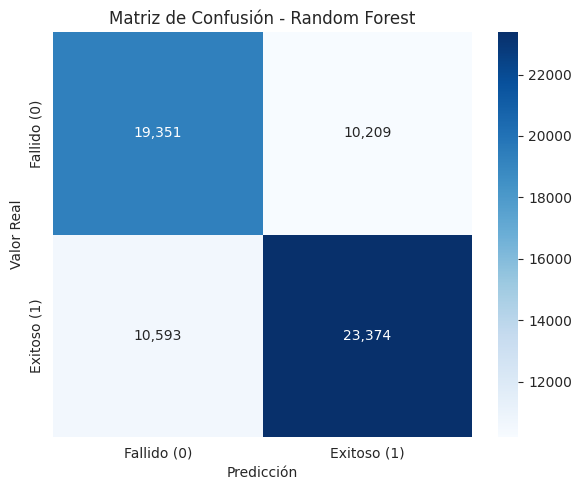

In [63]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt=',d', cmap='Blues',
    xticklabels=['Fallido (0)', 'Exitoso (1)'],
    yticklabels=['Fallido (0)', 'Exitoso (1)']
)
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()


####**Importancia de variables (Feature Importance)**

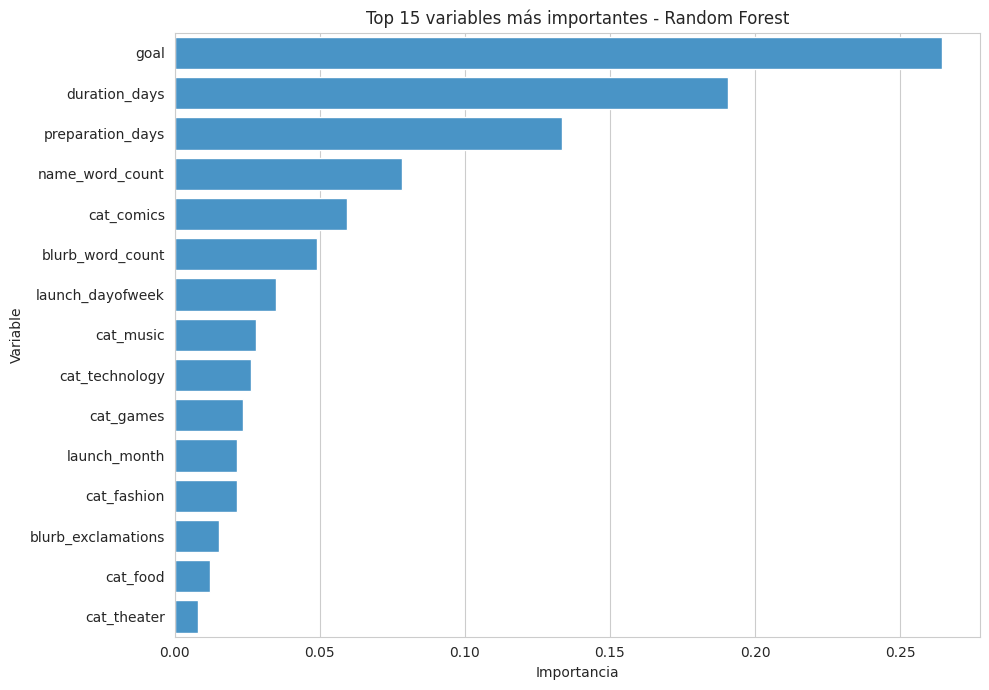

,0
goal,0.26
duration_days,0.19
preparation_days,0.13
name_word_count,0.08
cat_comics,0.06
blurb_word_count,0.05
launch_dayofweek,0.03
cat_music,0.03
cat_technology,0.03
cat_games,0.02


In [64]:
# Importancia de variables según el modelo Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

top_n = 15
plt.figure(figsize=(10, 7))
sns.barplot(x=importances.head(top_n).values, y=importances.head(top_n).index, color='#3498db')
plt.title(f'Top {top_n} variables más importantes - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

importances.head(top_n)


####**Optimización de hiperparámetros (Grid Search, Random Search)**

### **MODELO DECISION TREE**

####**Entrenamiento del modelo**



In [65]:
# ============================================================
# ENTRENAMIENTO: DECISION TREE
# ============================================================
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)

dt_model.fit(X_train, y_train)

print("Modelo Decision Tree entrenado correctamente.")

Modelo Decision Tree entrenado correctamente.


####**Evaluación del modelo**

In [66]:
# ============================================================
# EVALUACIÓN: DECISION TREE
# ============================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  MÉTRICAS DEL MODELO DECISION TREE")
print("=" * 55)
print(f"  Accuracy : {accuracy_score(y_test, y_pred)*100:.4f}%")
print(f"  Precision: {precision_score(y_test, y_pred)*100:.4f}%")
print(f"  Recall   : {recall_score(y_test, y_pred)*100:.4f}%")
print(f"  F1-score : {f1_score(y_test, y_pred)*100:.4f}%")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba)*100:.4f}%")
print("=" * 55)

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=['Fallido (0)', 'Exitoso (1)']))

  MÉTRICAS DEL MODELO DECISION TREE
  Accuracy : 65.3754%
  Precision: 67.7785%
  Recall   : 67.1799%
  F1-score : 67.4779%
  ROC-AUC  : 71.1887%

Reporte de clasificación:

              precision    recall  f1-score   support

 Fallido (0)       0.63      0.63      0.63     29560
 Exitoso (1)       0.68      0.67      0.67     33967

    accuracy                           0.65     63527
   macro avg       0.65      0.65      0.65     63527
weighted avg       0.65      0.65      0.65     63527



####**Matriz de confusión**

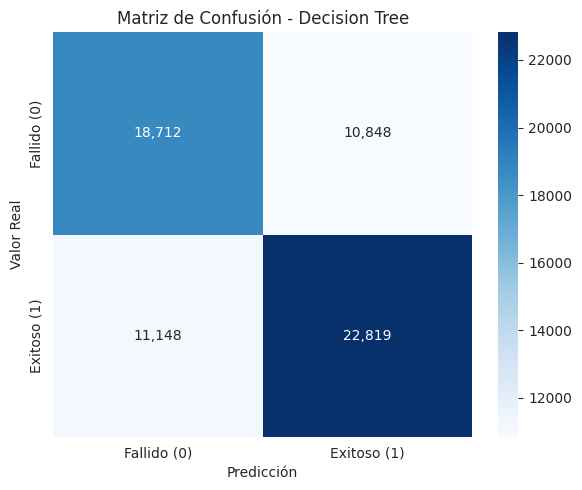

In [67]:
# ============================================================
# MATRIZ DE CONFUSIÓN: DECISION TREE
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt=',d', cmap='Blues',
    xticklabels=['Fallido (0)', 'Exitoso (1)'],
    yticklabels=['Fallido (0)', 'Exitoso (1)']
)
plt.title('Matriz de Confusión - Decision Tree')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

####**Optimización de hiperparámetros (Grid Search, Random Search)**

In [68]:
dt_param_grid = {
    'max_depth': [6, 8, 10, 12, 15, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid=dt_param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)
dt_grid.fit(X_train, y_train)
print("Mejores parámetros (DT - GridSearch):", dt_grid.best_params_)
print("Mejor F1 (CV):", dt_grid.best_score_)

dt_param_dist = {
    'max_depth': randint(4, 20),
    'min_samples_leaf': randint(1, 30),
    'min_samples_split': randint(2, 30),
    'criterion': ['gini', 'entropy']
}

dt_random = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_distributions=dt_param_dist,
    n_iter=30,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
dt_random.fit(X_train, y_train)
print("Mejores parámetros (DT - RandomSearch):", dt_random.best_params_)
print("Mejor F1 (CV):", dt_random.best_score_)

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Mejores parámetros (DT - GridSearch): {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 2}
Mejor F1 (CV): 0.6746323692939337
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Mejores parámetros (DT - RandomSearch): {'criterion': 'entropy', 'max_depth': 11, 'min_samples_leaf': 24, 'min_samples_split': 4}
Mejor F1 (CV): 0.677178654767705


### **MODELO LIGHTGBM**

####**Entrenamiento del modelo**



In [69]:
# ============================================================
# ENTRENAMIENTO: LIGHTGBM
# ============================================================
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=12,
    min_child_samples=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

lgbm_model.fit(X_train, y_train)

print("Modelo LightGBM entrenado correctamente.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 135869, number of negative: 118237
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008605 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 696
[LightGBM] [Info] Number of data points in the train set: 254106, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Modelo LightGBM entrenado correctamente.


####**Evaluación del modelo**

In [70]:
# ============================================================
# EVALUACIÓN: LIGHTGBM
# ============================================================
y_pred = lgbm_model.predict(X_test)
y_proba = lgbm_model.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  MÉTRICAS DEL MODELO LIGHTGBM")
print("=" * 55)
print(f"  Accuracy : {accuracy_score(y_test, y_pred)*100:.4f}%")
print(f"  Precision: {precision_score(y_test, y_pred)*100:.4f}%")
print(f"  Recall   : {recall_score(y_test, y_pred)*100:.4f}%")
print(f"  F1-score : {f1_score(y_test, y_pred)*100:.4f}%")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba)*100:.4f}%")
print("=" * 55)

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=['Fallido (0)', 'Exitoso (1)']))

  MÉTRICAS DEL MODELO LIGHTGBM
  Accuracy : 68.0876%
  Precision: 70.4303%
  Recall   : 69.4910%
  F1-score : 69.9575%
  ROC-AUC  : 75.0515%

Reporte de clasificación:

              precision    recall  f1-score   support

 Fallido (0)       0.65      0.66      0.66     29560
 Exitoso (1)       0.70      0.69      0.70     33967

    accuracy                           0.68     63527
   macro avg       0.68      0.68      0.68     63527
weighted avg       0.68      0.68      0.68     63527



####**Matriz de confusión**

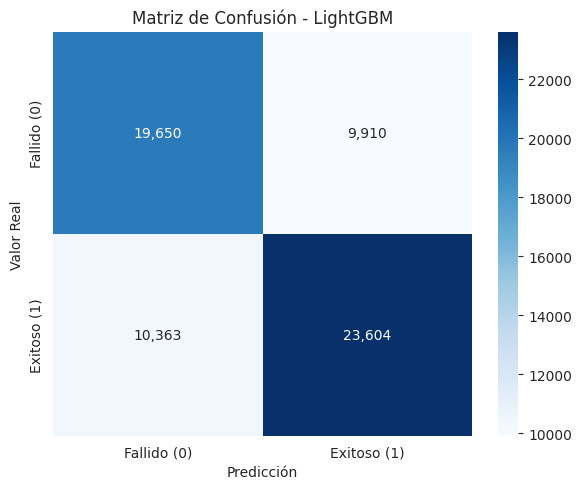

In [71]:
# ============================================================
# MATRIZ DE CONFUSIÓN: LIGHTGBM
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt=',d', cmap='Blues',
    xticklabels=['Fallido (0)', 'Exitoso (1)'],
    yticklabels=['Fallido (0)', 'Exitoso (1)']
)
plt.title('Matriz de Confusión - LightGBM')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

####**Optimización de hiperparámetros (Grid Search, Random Search)**

In [72]:
lgbm_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 12, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'min_child_samples': [5, 10, 20]
}

lgbm_grid = GridSearchCV(
    estimator=LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced', verbose=-1),
    param_grid=lgbm_param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)
lgbm_grid.fit(X_train, y_train)
print("Mejores parámetros (LightGBM - GridSearch):", lgbm_grid.best_params_)
print("Mejor F1 (CV):", lgbm_grid.best_score_)

lgbm_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(4, 20),
    'learning_rate': uniform(0.01, 0.2),
    'num_leaves': randint(20, 150),
    'min_child_samples': randint(5, 50),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

lgbm_random = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced', verbose=-1),
    param_distributions=lgbm_param_dist,
    n_iter=30,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
lgbm_random.fit(X_train, y_train)
print("Mejores parámetros (LightGBM - RandomSearch):", lgbm_random.best_params_)
print("Mejor F1 (CV):", lgbm_random.best_score_)

Fitting 3 folds for each of 324 candidates, totalling 972 fits


KeyboardInterrupt: 

### **MODELO NAIVE BAYES**

####**Entrenamiento del modelo**



In [73]:
from sklearn.naive_bayes import GaussianNB

# Instanciamos el modelo Naïve Bayes
# Usamos GaussianNB porque nuestras variables predictoras son numéricas/continuas
nb_model = GaussianNB()

# Entrenamos el modelo
nb_model.fit(X_train, y_train)

print("Modelo Naïve Bayes entrenado correctamente.")

Modelo Naïve Bayes entrenado correctamente.


####**Evaluación del modelo**

In [74]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Predicciones de clase y probabilidades
y_pred_nb = nb_model.predict(X_test)
y_proba_nb = nb_model.predict_proba(X_test)[:, 1]

print("=" * 55)
print(" MÉTRICAS DEL MODELO NAÏVE BAYES")
print("=" * 55)
print(f" Accuracy  : {accuracy_score(y_test, y_pred_nb)*100:.4f}%")
print(f" Precision : {precision_score(y_test, y_pred_nb)*100:.4f}%")
print(f" Recall    : {recall_score(y_test, y_pred_nb)*100:.4f}%")
print(f" F1-score  : {f1_score(y_test, y_pred_nb)*100:.4f}%")
print(f" ROC-AUC   : {roc_auc_score(y_test, y_proba_nb)*100:.4f}%")
print("=" * 55)

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_nb, target_names=['Fallido (0)', 'Exitoso (1)']))

 MÉTRICAS DEL MODELO NAÏVE BAYES
 Accuracy  : 61.5534%
 Precision : 60.0239%
 Recall    : 84.1169%
 F1-score  : 70.0569%
 ROC-AUC   : 68.0069%

Reporte de clasificación:

              precision    recall  f1-score   support

 Fallido (0)       0.66      0.36      0.46     29560
 Exitoso (1)       0.60      0.84      0.70     33967

    accuracy                           0.62     63527
   macro avg       0.63      0.60      0.58     63527
weighted avg       0.63      0.62      0.59     63527



####**Matriz de confusión**

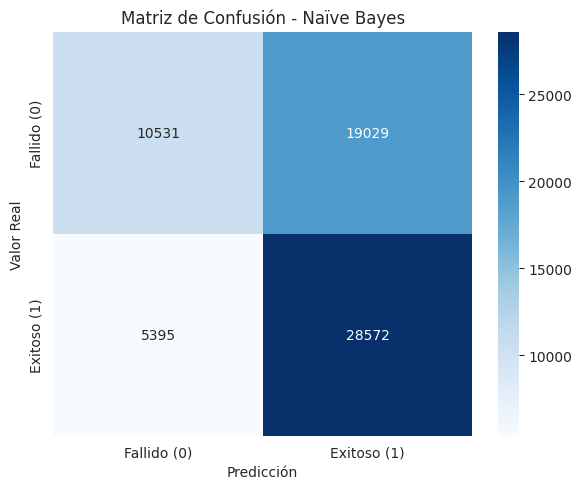

In [75]:
# Calculamos la matriz
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Graficamos
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_nb, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Fallido (0)', 'Exitoso (1)'],
    yticklabels=['Fallido (0)', 'Exitoso (1)']
)
plt.title('Matriz de Confusión - Naïve Bayes')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

####**Importancia de variables**

In [76]:
from sklearn.inspection import permutation_importance

print("Calculando la importancia de variables para Naïve Bayes...")

# Calculamos la importancia permutando las variables
resultado_imp = permutation_importance(nb_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)

importancias_nb = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': resultado_imp.importances_mean
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancias_nb.head(15), palette='Blues_r')
plt.title('Top 15 Variables más Importantes (Permutation) - Naïve Bayes')
plt.xlabel('Caída en Exactitud (Accuracy) al ocultar la variable')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# Imprimir los valores numéricos
print(importancias_nb.head(15))

Calculando la importancia de variables para Naïve Bayes...


KeyboardInterrupt: 

####**Optimización de hiperparámetros (Grid Search, Random Search)**

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Naïve Bayes solo tiene un hiperparámetro principal para optimizar: var_smoothing
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=20)
}
print("--- INICIANDO OPTIMIZACIÓN CON RANDOM SEARCH ---")
random_search_nb = RandomizedSearchCV(
    estimator=GaussianNB(),
    param_distributions=param_grid_nb, n_iter=10, cv=3, scoring='accuracy', random_state=42, n_jobs=-1
)
random_search_nb.fit(X_train, y_train)
print(f"Mejor parámetro encontrado (Random Search): {random_search_nb.best_params_}")
print(f"Accuracy de validación cruzada: {random_search_nb.best_score_*100:.4f}%\n")


print("--- INICIANDO OPTIMIZACIÓN CON GRID SEARCH ---")
grid_search_nb = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid_nb, cv=3, scoring='accuracy', n_jobs=-1
)
grid_search_nb.fit(X_train, y_train)
print(f"Mejor parámetro encontrado (Grid Search): {grid_search_nb.best_params_}")
print(f"Accuracy de validación cruzada: {grid_search_nb.best_score_*100:.4f}%\n")

# Evaluación final con el modelo óptimo
nb_model_opt = grid_search_nb.best_estimator_
y_pred_nb_opt = nb_model_opt.predict(X_test)

print("=" * 55)
print(" MÉTRICAS DEL MODELO NAÏVE BAYES OPTIMIZADO")
print("=" * 55)
print(f" Accuracy Final : {accuracy_score(y_test, y_pred_nb_opt)*100:.4f}%")
print("=" * 55)

### **MODELO XGBOOST**

####**Entrenamiento del modelo**



In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)


####**Evaluación del modelo**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

print("="*55)
print(" MÉTRICAS DEL MODELO XGBOOST")
print("="*55)

print(f"Accuracy  : {accuracy_score(y_test,y_pred_xgb)*100:.4f}%")
print(f"Precision : {precision_score(y_test,y_pred_xgb)*100:.4f}%")
print(f"Recall    : {recall_score(y_test,y_pred_xgb)*100:.4f}%")
print(f"F1 Score  : {f1_score(y_test,y_pred_xgb)*100:.4f}%")
print(f"ROC AUC   : {roc_auc_score(y_test,y_proba_xgb):.4f}")

print("\nReporte de Clasificación")
print(classification_report(y_test,y_pred_xgb))

####**Matriz de confusión**

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fallido (0)','Exitoso (1)'],
    yticklabels=['Fallido (0)','Exitoso (1)']
)

plt.title("Matriz de Confusión - XGBoost")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

####**Importancia de variables**

####**Optimización de hiperparámetros (Grid Search, Random Search)**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

param_dist = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.7,0.8,1],
    'colsample_bytree':[0.7,0.8,1]
}

print("Iniciando Random Search...")

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Mejores parámetros (Random Search):")
print(random_search.best_params_)
print(f"Accuracy: {random_search.best_score_:.4f}")

print("\nIniciando Grid Search...")

grid = {
    'n_estimators':[random_search.best_params_['n_estimators']],
    'max_depth':[random_search.best_params_['max_depth']],
    'learning_rate':[random_search.best_params_['learning_rate']],
    'subsample':[random_search.best_params_['subsample']],
    'colsample_bytree':[random_search.best_params_['colsample_bytree']]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nMejores parámetros (Grid Search):")
print(grid_search.best_params_)
print(f"Accuracy: {grid_search.best_score_:.4f}")

### **MODELO SVM**

####**Entrenamiento del modelo**

---





In [ ]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    random_state=42,
    max_iter=2000,
    dual='auto'
)

svm_model.fit(X_train_scaled, y_train)

print("Modelo SVM (LinearSVC) entrenado correctamente con datos estandarizados.")

####**Evaluación del modelo**

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

y_pred = svm_model.predict(X_test_scaled)
y_proba = None
if hasattr(svm_model, "decision_function"):
    y_scores = svm_model.decision_function(X_test_scaled)
    y_proba = 1 / (1 + np.exp(-y_scores))

print("=" * 55)
print("  MÉTRICAS DEL MODELO SVM (LinearSVC)")
print("=" * 55)
print(f"  Accuracy : {accuracy_score(y_test, y_pred)*100:.4f}%")
print(f"  Precision: {precision_score(y_test, y_pred)*100:.4f}%")
print(f"  Recall   : {recall_score(y_test, y_pred)*100:.4f}%")
print(f"  F1-score : {f1_score(y_test, y_pred)*100:.4f}%")
if y_proba is not None:
    print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba)*100:.4f}%")
print("=" * 55)
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=['Fallido (0)', 'Exitoso (1)']))



####**Matriz de confusión**

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Fallido (0)', 'Exitoso (1)'],
            yticklabels=['Fallido (0)', 'Exitoso (1)'])
plt.title('Matriz de Confusión - SVM (LinearSVC)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

####**Importancia de variables**

In [ ]:
coefs = pd.Series(
    svm_model.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

top_n = 15
plt.figure(figsize=(10, 7))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in coefs.head(top_n)]
sns.barplot(x=coefs.head(top_n).values, y=coefs.head(top_n).index, palette=colors)
plt.title(f'Top {top_n} Coeficientes - SVM (LinearSVC)')
plt.xlabel('Coeficiente')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

coefs.head(top_n)

####**Optimización de hiperparámetros (Grid Search, Random Search)**

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform, loguniform

svm_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'loss': ['squared_hinge'],
    'max_iter': [2000]
}
svm_grid = GridSearchCV(
    estimator=LinearSVC(class_weight='balanced', random_state=42, dual='auto'),
    param_grid=svm_param_grid, scoring='f1', cv=3, n_jobs=-1, verbose=1
)
svm_grid.fit(X_train_scaled, y_train)
print("Mejores parámetros (SVM - GridSearch):", svm_grid.best_params_)
print("Mejor F1 (CV):", svm_grid.best_score_)

svm_param_dist = {
    'C': loguniform(0.001, 1000),
    'penalty': ['l1', 'l2'],
    'loss': ['squared_hinge'],
    'max_iter': [2000]
}
svm_random = RandomizedSearchCV(
    estimator=LinearSVC(class_weight='balanced', random_state=42, dual='auto'),
    param_distributions=svm_param_dist, n_iter=20, scoring='f1', cv=3, n_jobs=-1, random_state=42, verbose=1
)
svm_random.fit(X_train_scaled, y_train)
print("Mejores parámetros (SVM - RandomSearch):", svm_random.best_params_)
print("Mejor F1 (CV):", svm_random.best_score_)

### **MODELO LOGISTIC REGRESSION**

####**Entrenamiento del modelo**



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
# 1. Instanciamos el escalador estándar
scaler = StandardScaler()

# 2. Entrenamos el escalador SOLO con los datos de entrenamiento y transformamos ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Convertimos los resultados de vuelta a DataFrame para no perder los nombres de las columnas

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Datos escalados correctamente. Ahora todas las variables compiten en igualdad de condiciones matemáticas.")

# El modelo ya no necesita iterar excesivamente porque los datos están escalados
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# ATENCIÓN: Usamos los datos escalados
lr_model.fit(X_train_scaled, y_train)

print("Modelo Logistic Regression entrenado correctamente con datos estandarizados.")

####**Evaluación del modelo**

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
# ATENCIÓN: Usamos los datos de prueba escalados
y_pred = lr_model.predict(X_test_scaled)
y_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=" * 55)
print(" MÉTRICAS DEL MODELO LOGISTIC REGRESSION (ESCALADO)")
print("=" * 55)
print(f" Accuracy  : {accuracy_score(y_test, y_pred)*100:.4f}%")
print(f" Precision : {precision_score(y_test, y_pred)*100:.4f}%")
print(f" Recall    : {recall_score(y_test, y_pred)*100:.4f}%")
print(f" F1-score  : {f1_score(y_test, y_pred)*100:.4f}%")
print(f" ROC-AUC   : {roc_auc_score(y_test, y_proba)*100:.4f}%")
print("=" * 55)

####**Matriz de confusión**

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fallido (0)', 'Exitoso (1)'],
            yticklabels=['Fallido (0)', 'Exitoso (1)'])
plt.title('Matriz de Confusión - Logistic Regression')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

####**Importancia de variables**

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# 1. Feature Importance REAL
importancias_df = pd.DataFrame({
    'Variable': X_train_scaled.columns,
    'Importancia': abs(lr_model.coef_[0])
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancias_df.head(15), palette='Blues_r')
plt.title('Top 15 Variables más Importantes - Logistic Regression (Escalado)')
plt.tight_layout()
plt.show()

####**Optimización de hiperparámetros (Grid Search, Random Search)**

In [ ]:
# 2. Optimización (Grid/Random Search) usando datos escalados
param_grid = {'C': np.logspace(-3, 3, 10), 'solver': ['lbfgs', 'liblinear']}

grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1
)
# Entrenamos el GridSearch con los datos escalados
grid_search_lr.fit(X_train_scaled, y_train)

print(f"\nMejor parámetro encontrado (Grid Search): {grid_search_lr.best_params_}")
lr_model_opt = grid_search_lr.best_estimator_
y_pred_opt = lr_model_opt.predict(X_test_scaled)
print(f"Accuracy Final del modelo optimizado: {accuracy_score(y_test, y_pred_opt)*100:.4f}%")

### **MODELO Red Neuronal (MLPClassifier)**

####**Entrenamiento del modelo**



In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)

print("Modelo de Red Neuronal (MLP) entrenado correctamente.")
print(f"Número de iteraciones hasta convergencia: {nn_model.n_iter_}")

####**Evaluación del modelo**

In [ ]:
y_pred_nn = nn_model.predict(X_test_scaled)
y_proba_nn = nn_model.predict_proba(X_test_scaled)[:, 1]

print("=" * 55)
print("  MÉTRICAS DEL MODELO RED NEURONAL (MLP)")
print("=" * 55)
print(f"  Accuracy : {accuracy_score(y_test, y_pred_nn)*100:.4f}%")
print(f"  Precision: {precision_score(y_test, y_pred_nn)*100:.4f}%")
print(f"  Recall   : {recall_score(y_test, y_pred_nn)*100:.4f}%")
print(f"  F1-score : {f1_score(y_test, y_pred_nn)*100:.4f}%")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba_nn)*100:.4f}%")
print("=" * 55)

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_nn, target_names=['Fallido (0)', 'Exitoso (1)']))

####**Matriz de confusión**

In [ ]:
cm_nn = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_nn, annot=True, fmt=',d', cmap='Blues',
    xticklabels=['Fallido (0)', 'Exitoso (1)'],
    yticklabels=['Fallido (0)', 'Exitoso (1)']
)
plt.title('Matriz de Confusión - Red Neuronal (MLP)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

####**Importancia de variables**

In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    nn_model, X_test_scaled, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

importances_nn = pd.Series(perm_result.importances_mean, index=X.columns)
importances_nn = importances_nn.sort_values(ascending=False)

top_n = 15
plt.figure(figsize=(10, 7))
sns.barplot(x=importances_nn.head(top_n).values, y=importances_nn.head(top_n).index, color='#9b59b6')
plt.title(f'Top {top_n} variables más importantes - Red Neuronal (Permutation Importance)')
plt.xlabel('Importancia (caída en accuracy al permutar)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

importances_nn.head(top_n)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(nn_model.loss_curve_, color='#2c3e50')
plt.title('Curva de Pérdida durante el Entrenamiento - Red Neuronal (MLP)')
plt.xlabel('Iteración')
plt.ylabel('Pérdida (Log-loss)')
plt.tight_layout()
plt.show()

#### **Optimización de Hiperparámetros (RandomizedSearchCV)**
Se utiliza `RandomizedSearchCV` con validación cruzada estratificada de 3 particiones para
explorar 12 combinaciones del espacio de búsqueda. Para reducir el tiempo de cómputo, la
búsqueda se realiza sobre una submuestra estratificada de 20,000 registros del set de
entrenamiento. El modelo final se reentrena sobre el set completo con los mejores
hiperparámetros encontrados.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, StratifiedShuffleSplit

# ── Submuestra estratificada (más rápido sin sacrificar representatividad) ──
sss = StratifiedShuffleSplit(n_splits=1, train_size=20_000, random_state=42)
idx_sub, _ = next(sss.split(X_train_scaled, y_train))
X_search = X_train_scaled[idx_sub]
y_search  = y_train.iloc[idx_sub]

# ── Espacio de hiperparámetros a explorar ───────────────────────────────────
param_dist = {
    'hidden_layer_sizes'  : [(64, 32), (64, 64), (128, 64), (128, 64, 32), (256, 128)],
    'activation'          : ['relu', 'tanh'],
    'alpha'               : [1e-5, 1e-4, 1e-3],
    'learning_rate_init'  : [5e-4, 1e-3, 5e-3],
}

# ── RandomizedSearchCV con CV estratificado ─────────────────────────────────
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    estimator=MLPClassifier(
        solver='adam', max_iter=200,
        early_stopping=True, n_iter_no_change=10,
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=12,               # 12 combinaciones aleatorias
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=True
)

rs.fit(X_search, y_search)

print("=" * 55)
print("  MEJORES HIPERPARÁMETROS ENCONTRADOS")
print("=" * 55)
for param, valor in rs.best_params_.items():
    print(f"  {param:<25}: {valor}")
print(f"\n  ROC-AUC promedio (CV) : {rs.best_score_:.4f}")
print("=" * 55)

In [ ]:
# ── Top 10 combinaciones evaluadas ──────────────────────────────────────────
cv_results = pd.DataFrame(rs.cv_results_)[[
    'param_hidden_layer_sizes', 'param_activation',
    'param_alpha', 'param_learning_rate_init',
    'mean_test_score', 'std_test_score', 'rank_test_score'
]].sort_values('rank_test_score')

cv_results.columns = ['Capas', 'Activación', 'Alpha', 'LR Init',
                       'AUC Promedio', 'Desv. Est.', 'Ranking']
cv_results['AUC Promedio'] = cv_results['AUC Promedio'].round(4)
cv_results['Desv. Est.']   = cv_results['Desv. Est.'].round(4)

display(cv_results.head(10).reset_index(drop=True))

In [ ]:
# ── Reentrenamiento en el set de entrenamiento completo ─────────────────────
nn_opt = MLPClassifier(
    **rs.best_params_,          # inyecta automáticamente los mejores params
    solver='adam',
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)

nn_opt.fit(X_train_scaled, y_train)

print(f"Modelo optimizado entrenado en {nn_opt.n_iter_} iteraciones.")

In [ ]:
# ── Predicciones del baseline (ya entrenado como nn_model) ──────────────────
y_pred_base  = nn_model.predict(X_test_scaled)
y_proba_base = nn_model.predict_proba(X_test_scaled)[:, 1]

# ── Predicciones del modelo optimizado ──────────────────────────────────────
y_pred_opt  = nn_opt.predict(X_test_scaled)
y_proba_opt = nn_opt.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("  COMPARACIÓN: MLP BASELINE vs MLP OPTIMIZADO")
print("=" * 60)
print(f"{'Métrica':<15} {'Baseline':>12} {'Optimizado':>12} {'Δ':>10}")
print("-" * 60)

metricas_comp = {
    'Accuracy' : (accuracy_score,  y_pred_base,  y_pred_opt),
    'Precision': (precision_score, y_pred_base,  y_pred_opt),
    'Recall'   : (recall_score,    y_pred_base,  y_pred_opt),
    'F1-Score' : (f1_score,        y_pred_base,  y_pred_opt),
}
for nombre, (fn, p_base, p_opt) in metricas_comp.items():
    vb = fn(y_test, p_base); vo = fn(y_test, p_opt)
    print(f"{nombre:<15} {vb*100:>11.4f}% {vo*100:>11.4f}% {(vo-vb)*100:>+9.4f}pp")

vb_auc = roc_auc_score(y_test, y_proba_base)
vo_auc = roc_auc_score(y_test, y_proba_opt)
print(f"{'ROC-AUC':<15} {vb_auc*100:>11.4f}% {vo_auc*100:>11.4f}% {(vo_auc-vb_auc)*100:>+9.4f}pp")
print("=" * 60)

print("\nReporte de clasificación (Optimizado):\n")
print(classification_report(y_test, y_pred_opt, target_names=['Fallido (0)', 'Exitoso (1)']))

In [ ]:
# ── Comparación de métricas Baseline vs Optimizado ──────────────────────────
metricas_list  = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
vals_base_plot = [accuracy_score(y_test,y_pred_base), precision_score(y_test,y_pred_base),
                  recall_score(y_test,y_pred_base), f1_score(y_test,y_pred_base), roc_auc_score(y_test,y_proba_base)]
vals_opt_plot  = [accuracy_score(y_test,y_pred_opt),  precision_score(y_test,y_pred_opt),
                  recall_score(y_test,y_pred_opt),  f1_score(y_test,y_pred_opt),  roc_auc_score(y_test,y_proba_opt)]

x = np.arange(len(metricas_list)); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Barras
bars1 = axes[0].bar(x - w/2, vals_base_plot, w, label='MLP Baseline',   color='#3498db', alpha=0.85)
bars2 = axes[0].bar(x + w/2, vals_opt_plot,  w, label='MLP Optimizado', color='#9b59b6', alpha=0.85)
for bar in [*bars1, *bars2]:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(metricas_list)
axes[0].set_ylim(0.60, 0.80); axes[0].set_ylabel('Score')
axes[0].set_title('MLP Baseline vs MLP Optimizado'); axes[0].legend()

# Matriz de confusión
cm_opt = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt=',d', cmap='Purples',
            xticklabels=['Fallido (0)','Exitoso (1)'],
            yticklabels=['Fallido (0)','Exitoso (1)'], ax=axes[1])
axes[1].set_title('Matriz de Confusión — MLP Optimizado')
axes[1].set_xlabel('Predicción'); axes[1].set_ylabel('Valor Real')

plt.tight_layout(); plt.show()

In [ ]:
# ── Curva de pérdida del modelo optimizado ───────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(nn_opt.loss_curve_, color='#9b59b6',
         label=f'MLP Optimizado ({nn_opt.n_iter_} iteraciones)')
plt.title('Curva de Pérdida durante el Entrenamiento — MLP Optimizado')
plt.xlabel('Iteración')
plt.ylabel('Pérdida (Log-loss)')
plt.legend()
plt.tight_layout()
plt.show()

### **Conclusiones de entrenamiento de modelos**



### **Optimización de parámetros del modelo ganador**

###